# Test `2D_Kernel_Torch` vs `2D_FFT_Torch` consistency <br/> with `Bump-Steerable` and `Morlet` wavelets

In [13]:
# Import useful libraries, test data path and STL modules

# Library imports
import numpy as np
import matplotlib.pyplot as plt

import os
import sys

# Add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + os.path.basename(PARENT_DIR))

# Path to test data
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print(
    "Dataset directory used:",
    ".../" + os.path.basename(PARENT_DIR) + DATA_TEST_PATH.split(os.path.basename(PARENT_DIR))[-1]
)

# STL package imports
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Parent directory added to sys.path: .../STL-Dev
Dataset directory used: .../STL-Dev/data/test
Working on device: mps


In [14]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Comparing Scattering statistics

In [15]:
# ----- Utils functions for visualization -----

# Plot and compare scattering coefficients of two ST data (e.g., Kernel vs FFT, with vs without NaN values, or with vs without PBC)
def plot_scattering_coeffs(st_data_dict, suptitle, L=None, plot_slopes=False):
    
    plt.figure(figsize=(10, 24))
    ls = [':', '--', '-.', '-']
    alpha = [1.0, 0.8, 0.7, 0.6]
    color = ['red', 'orange', 'black', 'blue']
    linewidth = [2.0, 1.6, 1.4, 1.2]

    # --- S1 ---
    plt.subplot(4,1,1)
    if L is not None and plot_slopes:
        # Plot steps of height 2**-j for j in range(J) and width width L
        J = list(st_data_dict.values())[0].S1.cpu().numpy().flatten().shape[0] // L
        steps = np.repeat(2.**(-np.arange(J)), L)
        steps = steps.flatten()
        steps *= list(st_data_dict.values())[0].S1.abs().cpu().numpy().flatten()[:L].mean()
        plt.plot(steps, color='gray', label=r'$\propto 2^{-j}$', linewidth=8, alpha=.5)
    for ind, (label, st_data) in enumerate(st_data_dict.items()):
        plt.plot(st_data.S1.abs().cpu().numpy().flatten(), label=label, ls=ls[ind], alpha=alpha[ind], color=color[ind], linewidth=linewidth[ind])
    plt.yscale('log')
    plt.title('S1')
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.legend()

    # --- S2 ---
    plt.subplot(4,1,2)
    if L is not None and plot_slopes:
        # Plot steps of height 2**-j for j in range(J) and width width L
        J = list(st_data_dict.values())[0].S1.cpu().numpy().flatten().shape[0] // L
        steps = np.repeat(4.**(-np.arange(J)), L)
        steps = steps.flatten()
        steps *= list(st_data_dict.values())[0].S2.abs().cpu().numpy().flatten()[:L].mean()
        plt.plot(steps, color='gray', label=r'$\propto 4^{-j}$', linewidth=8, alpha=.5)
    for ind, (label, st_data) in enumerate(st_data_dict.items()):
        plt.plot(st_data.S2.abs().cpu().numpy().flatten(), label=label, ls=ls[ind], alpha=alpha[ind], color=color[ind], linewidth=linewidth[ind])
    plt.yscale('log')
    plt.title('S2')
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.legend()

    # --- S3 ---
    plt.subplot(4,1,3)
    for ind, (label, st_data) in enumerate(st_data_dict.items()):
        plt.plot(st_data.S3.abs().cpu().numpy().flatten(), label=label, ls=ls[ind], alpha=alpha[ind], color=color[ind], linewidth=linewidth[ind])
    plt.yscale('log')
    plt.title('S3')
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.legend()

    # --- S4 ---
    plt.subplot(4,1,4)
    for ind, (label, st_data) in enumerate(st_data_dict.items()):
        plt.plot(st_data.S4.abs().cpu().numpy().flatten(), label=label, ls=ls[ind], alpha=alpha[ind], color=color[ind], linewidth=linewidth[ind])
    plt.yscale('log')
    plt.title('S4')
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.legend()

    plt.suptitle(suptitle, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    plt.show()  

def compare_kernel_fft(im, st_ops_fft, st_ops_kernel, pbc=True, norm="vanilla", norm_batch_mean=True, mean_along_batch=True, plot_slopes=False):
    
    # Instantiate kernel and FFT dataclass on the mono-channel image
    data_kernel = STL_2D_Kernel_Torch(im, pbc=pbc)
    data_fft    =    STL_2D_FFT_Torch(im, pbc=pbc)

    # Apply
    st_data_dict = {
        f"KNL {WType}": st_op.apply(data_kernel, norm=norm, norm_batch_mean=norm_batch_mean) for WType, st_op in st_ops_kernel.items()
    }
    st_data_dict.update({
        f"FFT {WType}": st_op.apply(   data_fft, norm=norm, norm_batch_mean=norm_batch_mean) for WType, st_op in st_ops_fft.items()
    })

    # Mean along batch dimension (if norm_batch_mean is True) 
    if mean_along_batch:
        for st_data in st_data_dict.values():
            st_data.S1 = st_data.S1.mean(dim=0, keepdim=True)
            st_data.S2 = st_data.S2.mean(dim=0, keepdim=True)
            st_data.S3 = st_data.S3.mean(dim=0, keepdim=True)
            st_data.S4 = st_data.S4.mean(dim=0, keepdim=True)

    # Plot and compare scattering coefficients
    plot_scattering_coeffs(
        st_data_dict,
        suptitle="ST Comparison (pbc={}, norm={}, norm_batch_mean={}, mean_along_batch={})".format(pbc, norm, norm_batch_mean, mean_along_batch),
        L=list(st_ops_fft.values())[0].L,
        plot_slopes=plot_slopes
    )

### PBC, no mask, monochannel

#### Test with noise

In [16]:
N = 256
batch = 10
L = 4
WTypes = ["Bump-Steerable", "Morlet"]
np.random.seed(0) # set random seed for reproducibility

noise = np.random.randn(batch, 1, N, N)

data_fft    =    STL_2D_FFT_Torch(noise, pbc=True)
data_kernel = STL_2D_Kernel_Torch(noise, pbc=True)

st_ops_fft    = {WType:    data_fft.get_ST_op(L=L, WType=WType) for WType in WTypes}
st_ops_kernel = {WType: data_kernel.get_ST_op(L=L, WType=WType) for WType in WTypes}

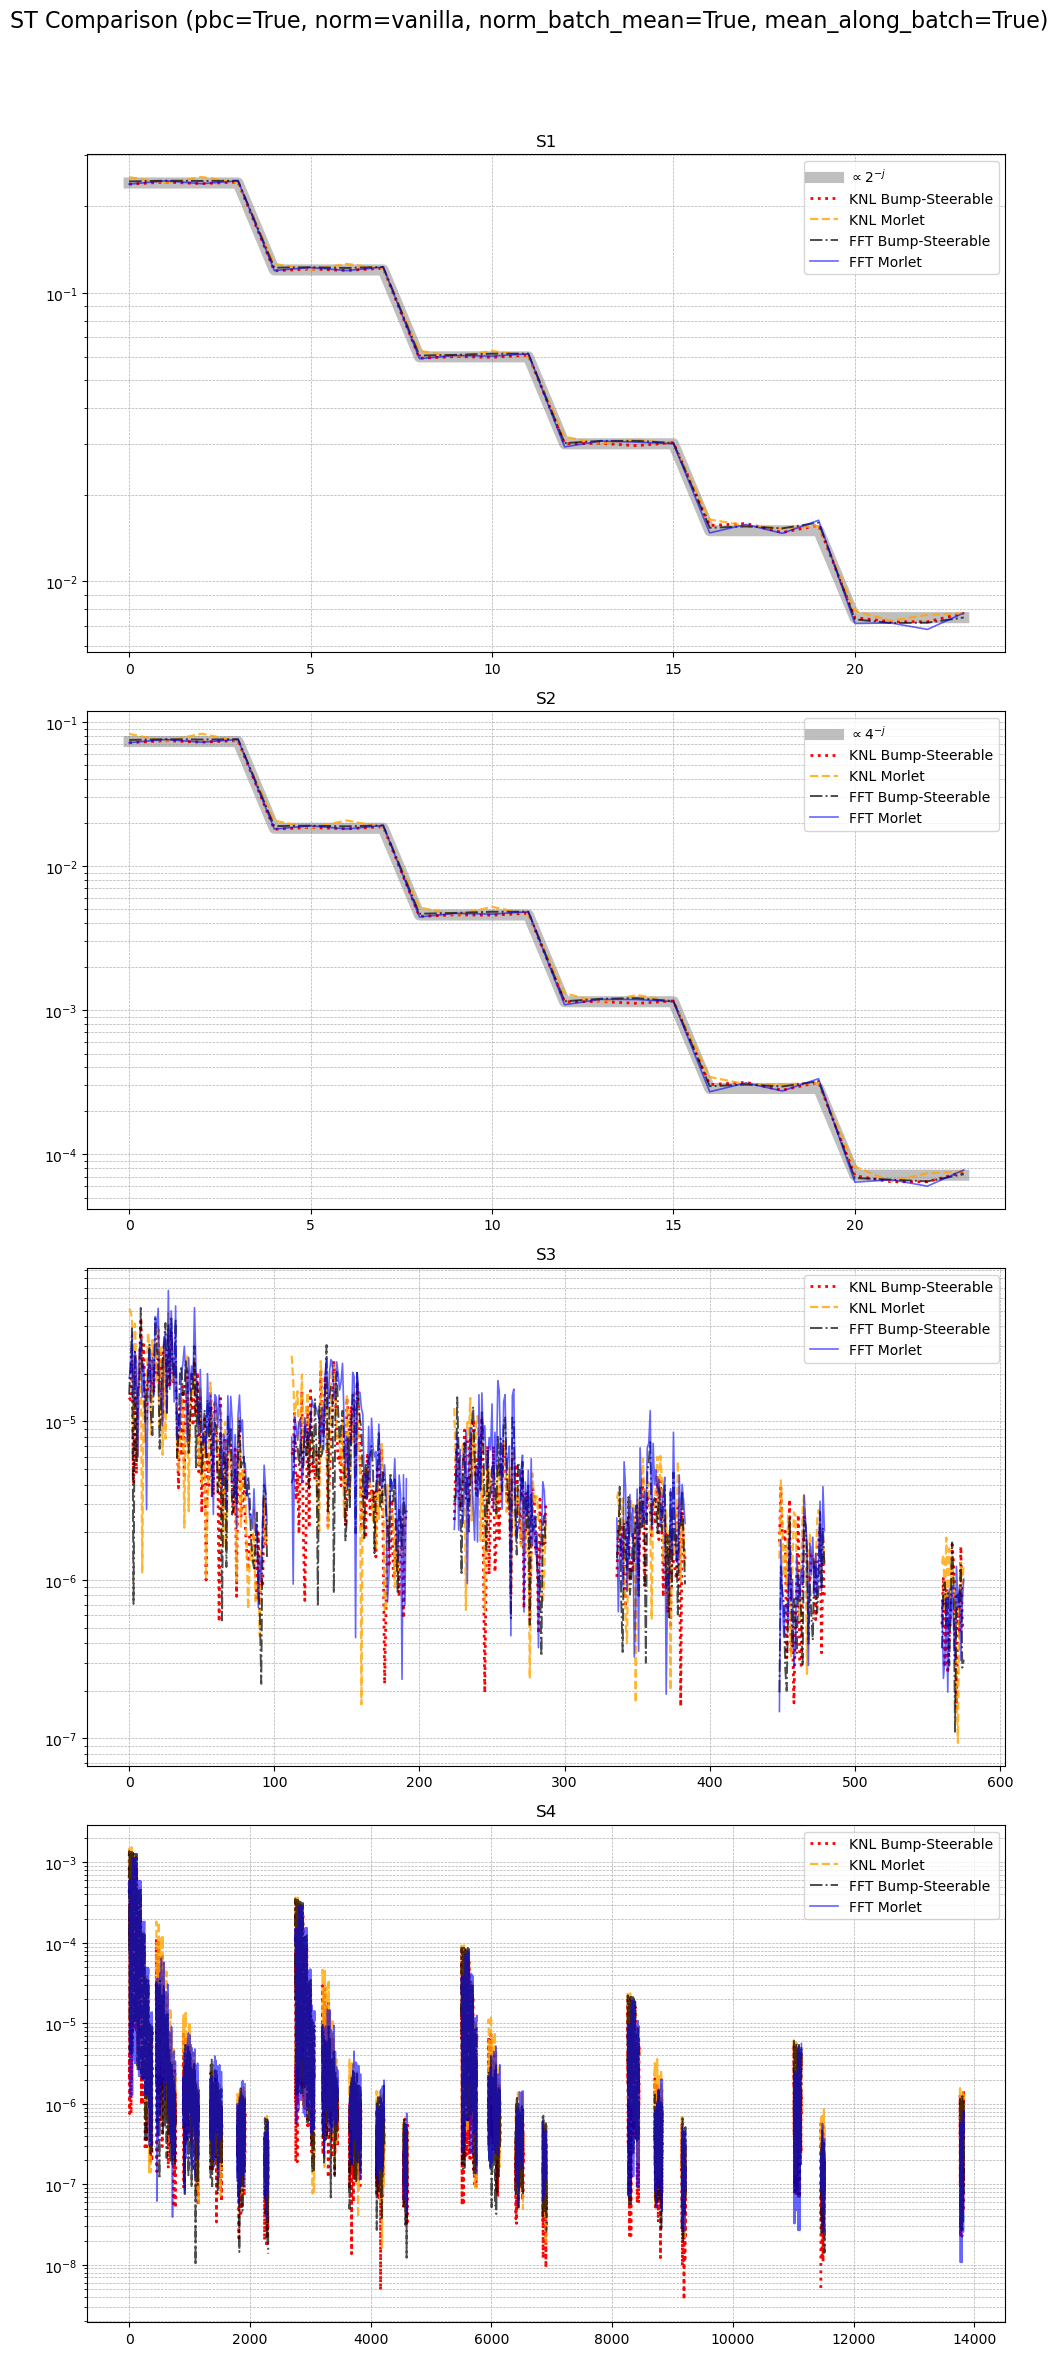

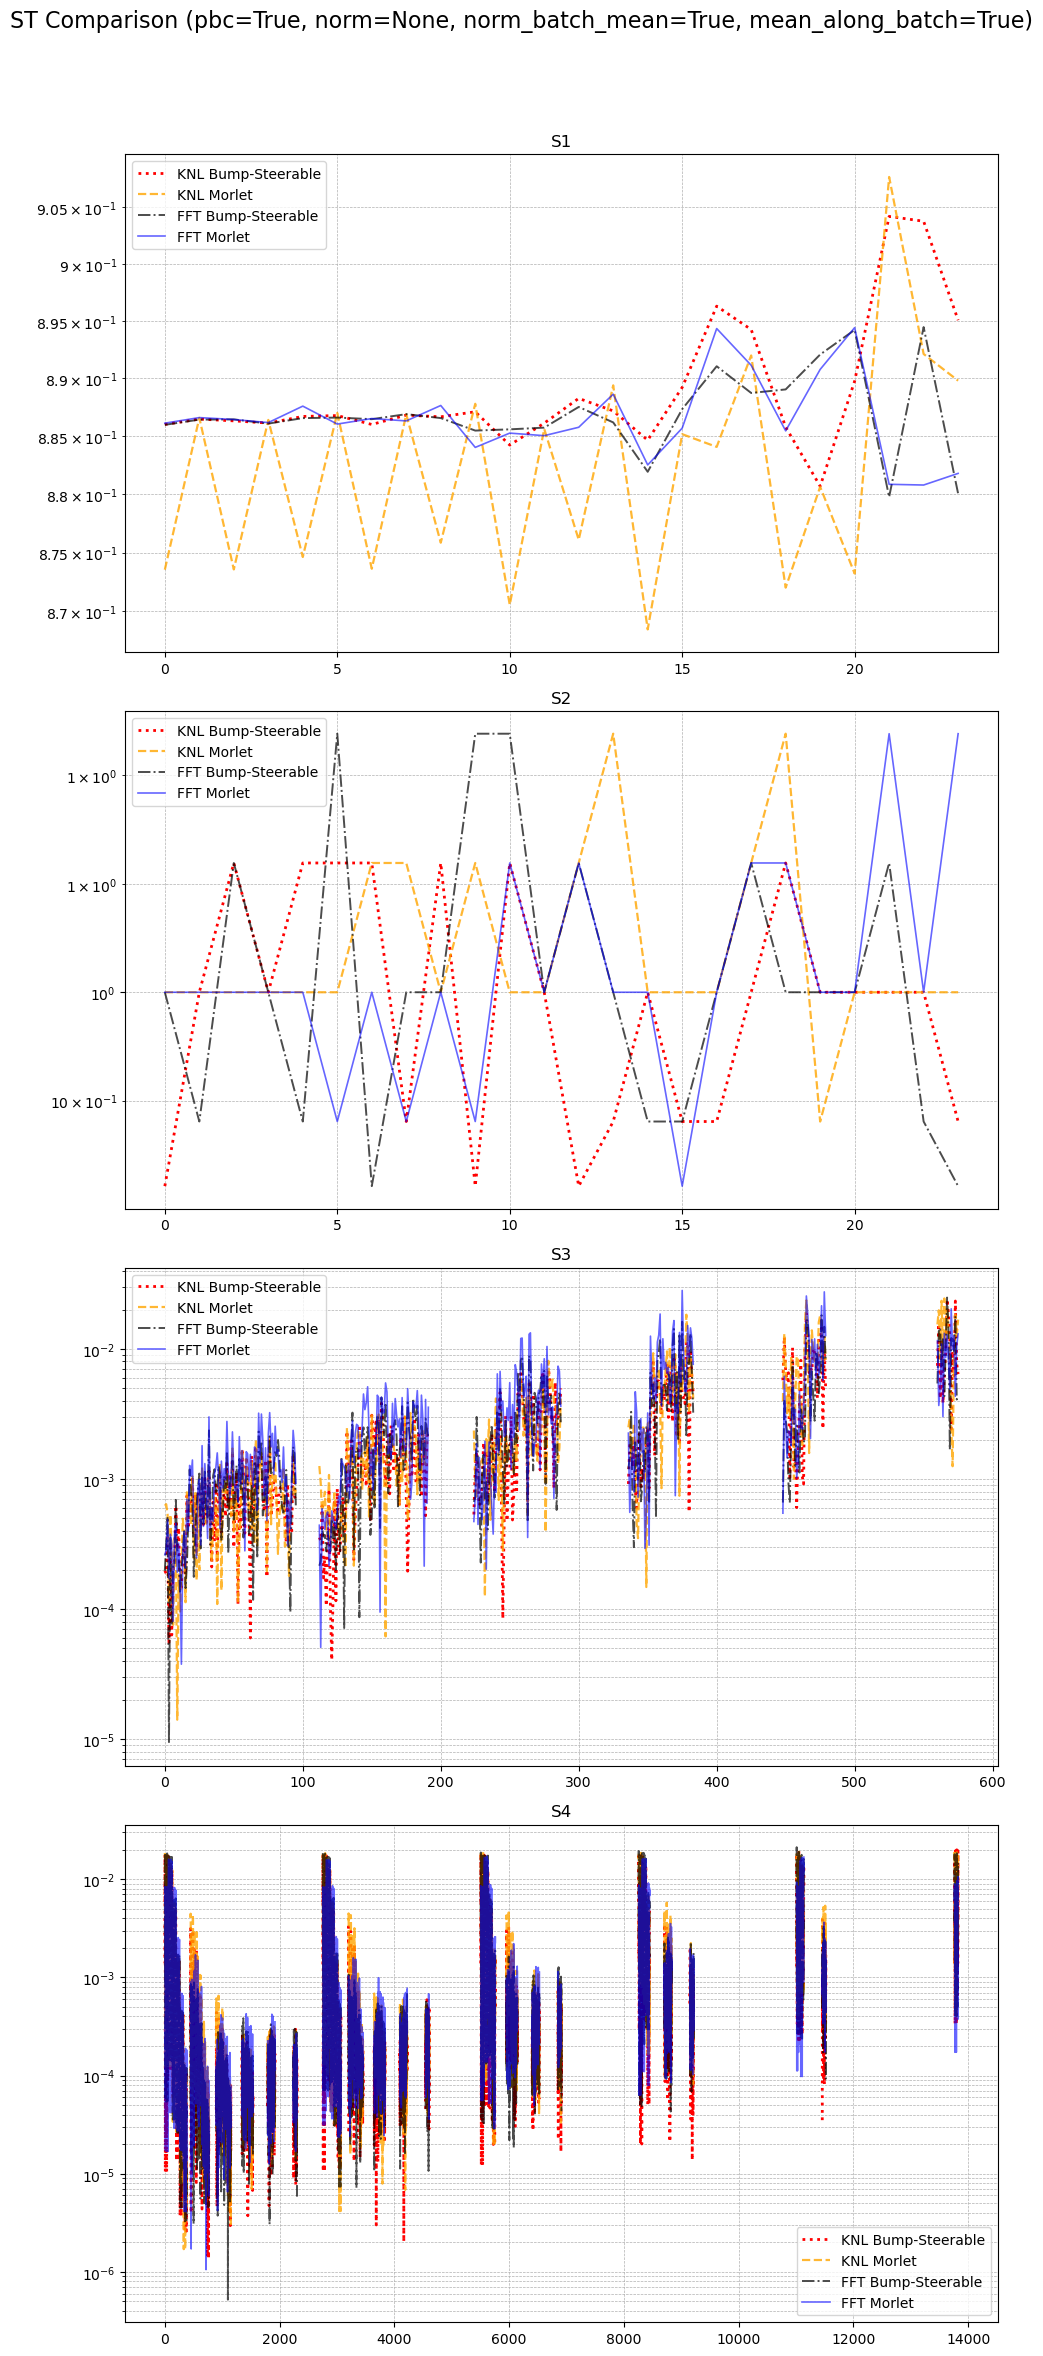

In [17]:
compare_kernel_fft(noise, st_ops_fft, st_ops_kernel, norm="vanilla", plot_slopes=True)
compare_kernel_fft(noise, st_ops_fft, st_ops_kernel, norm=None,      plot_slopes=False)

#### Test with simulation data

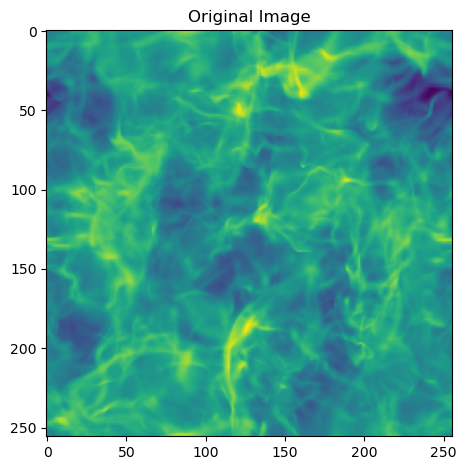

In [18]:
# Image loading
im = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:, None, :, :] # [Nb, Nc, Nx, Ny]
im_mono_channel = im[0, 0, :, :]

# Visualize loaded data
plt.imshow(im_mono_channel)
plt.title("Original Image")
plt.tight_layout()
plt.show()

In [19]:
data_fft    =    STL_2D_FFT_Torch(im_mono_channel, pbc=True)
data_kernel = STL_2D_Kernel_Torch(im_mono_channel, pbc=True)

st_ops_fft    = {WType:    data_fft.get_ST_op(L=L, WType=WType) for WType in WTypes}
st_ops_kernel = {WType: data_kernel.get_ST_op(L=L, WType=WType) for WType in WTypes}

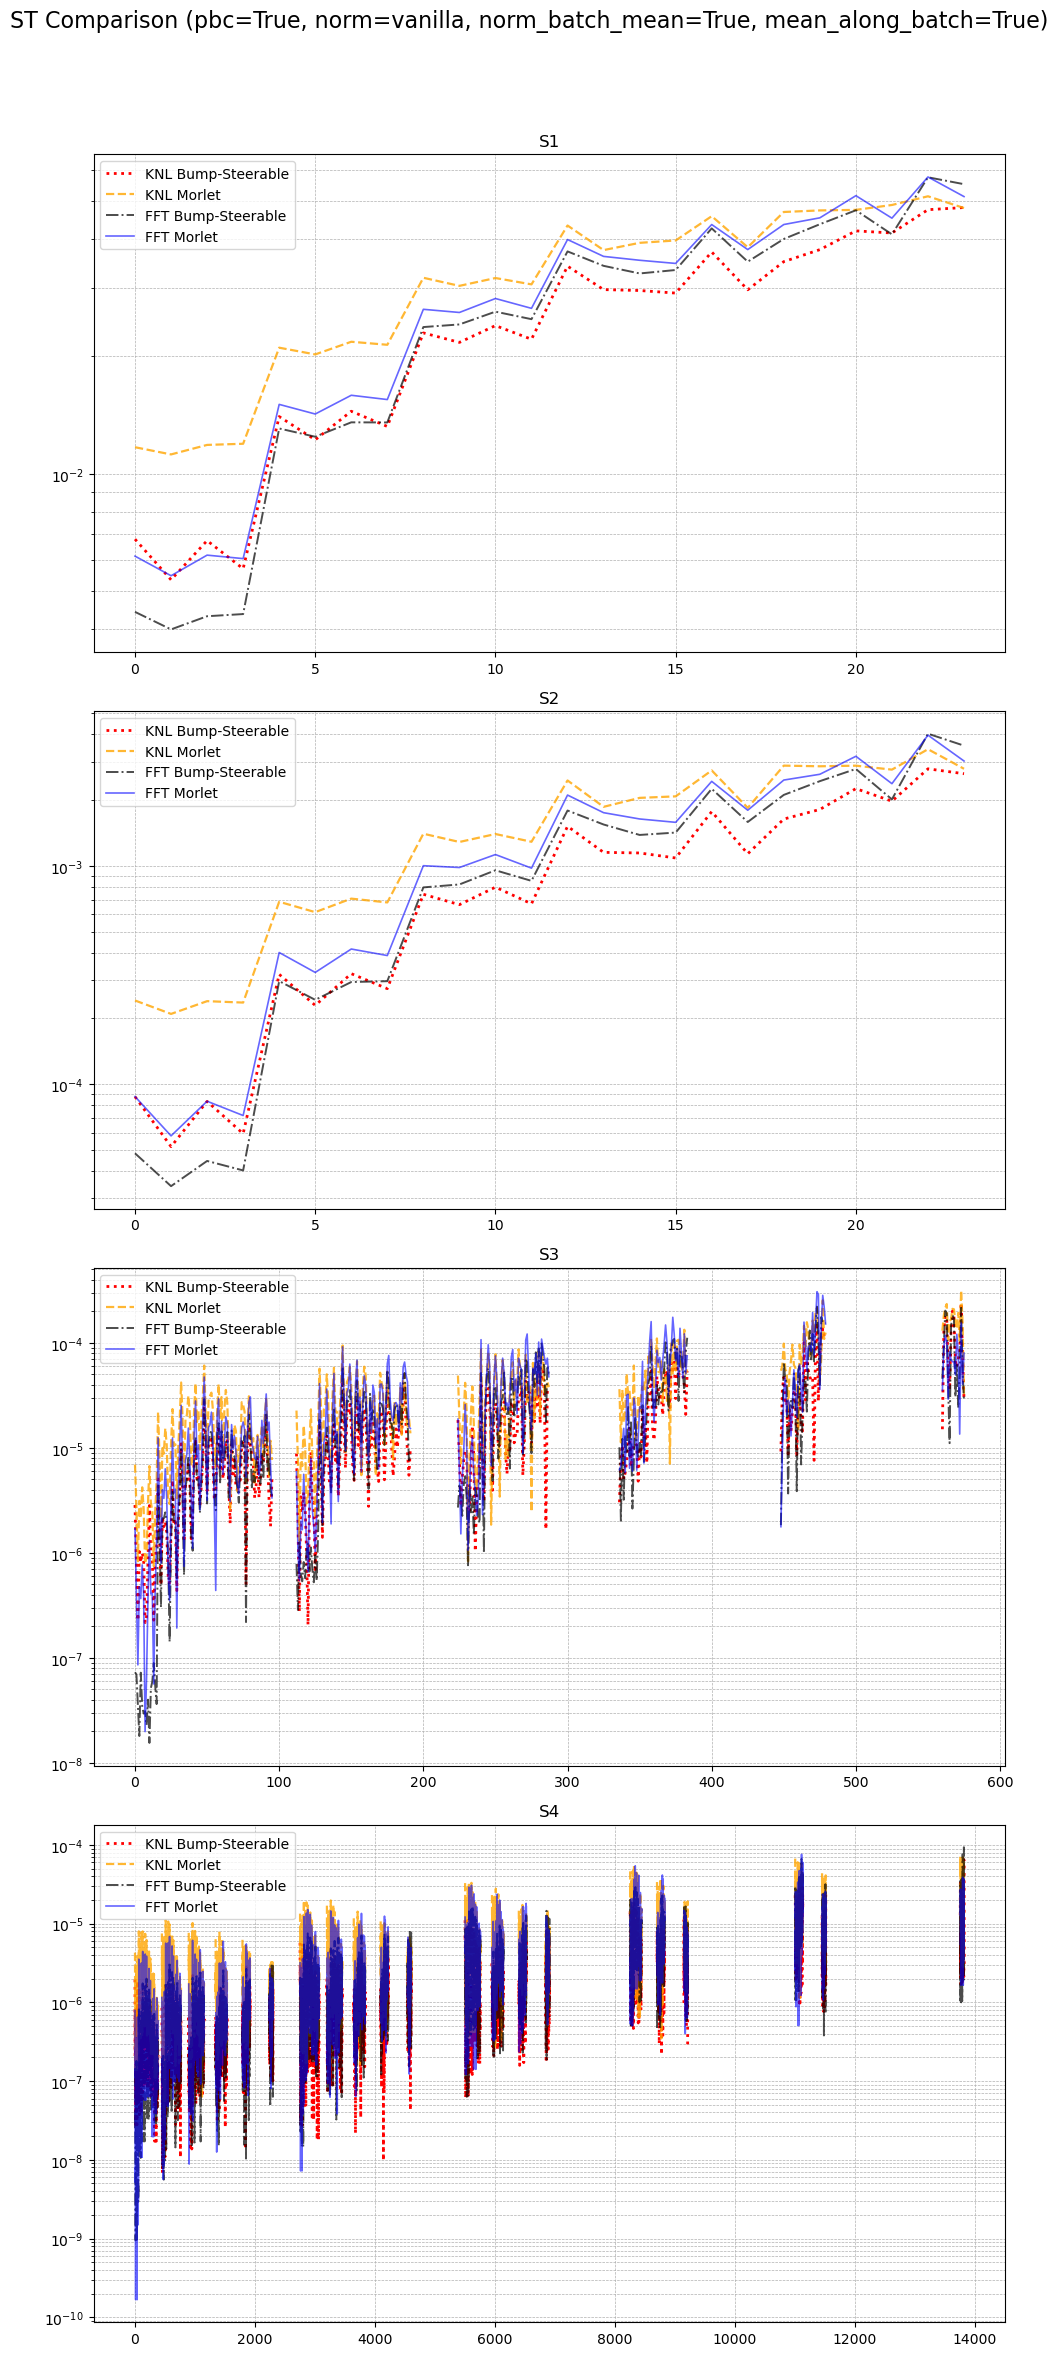

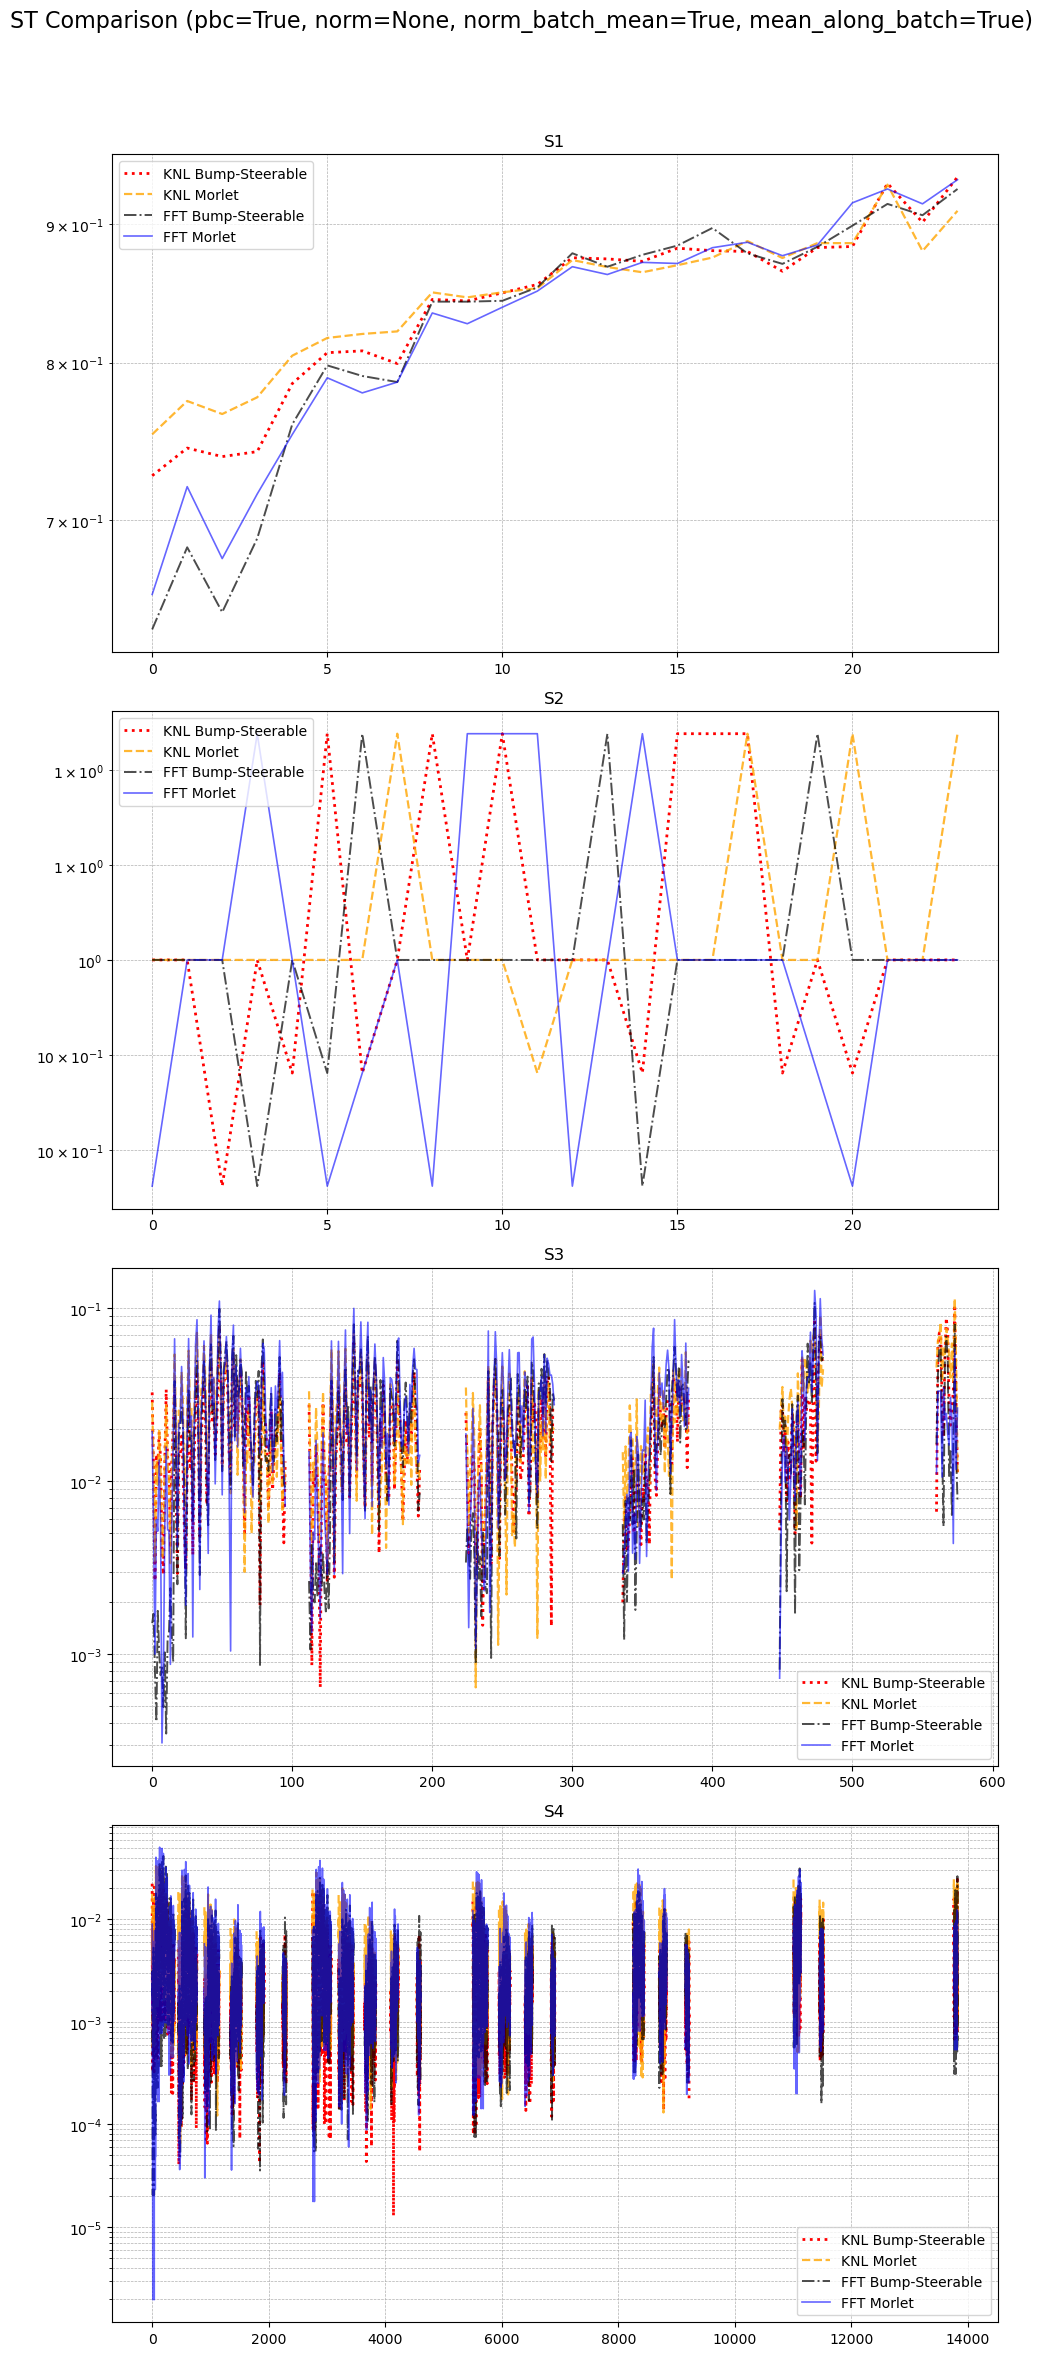

In [20]:
compare_kernel_fft(im_mono_channel, st_ops_fft, st_ops_kernel, norm="vanilla")
compare_kernel_fft(im_mono_channel, st_ops_fft, st_ops_kernel, norm=None)

## Comparing wavelets

### In Fourier space

In [21]:
import matplotlib.colors as colors

class MidpointNormalize(colors.Normalize):
    def __init__(self, vmin=None, vmax=None, midpoint=None):
        self.midpoint = midpoint
        colors.Normalize.__init__(self, vmin, vmax)

    def __call__(self, value):
        amp = max(self.vmax - self.midpoint, self.midpoint - self.vmin)
        x, y = [self.midpoint - amp, self.midpoint, self.midpoint + amp], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))
        
def get_effective_smooth_filter(N, st_op_kernel, plot=False):

    dirac = np.zeros((1, 1, N, N))
    dirac[0, 0, N//2, N//2] = 1

    data_kernel = STL_2D_Kernel_Torch(dirac, pbc=True)

    if plot:
        plt.imshow(np.abs(np.fft.fftshift(np.fft.fft2(dirac[0, 0]))), cmap='viridis')
        plt.colorbar()
        plt.title("FFT of Dirac")
        plt.tight_layout()
        plt.show()

    smooth_kernel = st_op_kernel.wavelet_op._get_smooth_kernel(
        device=data_kernel.array.device, dtype=data_kernel.array.dtype
    )
    padding_mode = st_op_kernel.wavelet_op.__class__._get_padding_mode(pbc=data_kernel.pbc)

    downsampled_arrays = [data_kernel.array]
    for dg in range(st_op_kernel.J):
        if st_op_kernel.wavelet_op.mask_full_res is None:  # no mask
            downsampled_arrays.append(
                st_op_kernel.wavelet_op._downsample_tensor(
                    x=downsampled_arrays[-1],
                    smooth_kernel=smooth_kernel,
                    dg_inc=1,
                    padding_mode=padding_mode,
                )
            )
        else:
            raise

    effective_smooth_filters = [np.fft.fft2(arr[0, 0].cpu().numpy()) for arr in downsampled_arrays]

    if plot:
        plt.imshow(np.abs(np.fft.fftshift(effective_smooth_filters[-1])), cmap='viridis')
        plt.colorbar()
        plt.title("FFT of downsampled Dirac")
        plt.tight_layout()
        plt.show()

    return effective_smooth_filters

#### Bump-Steerable

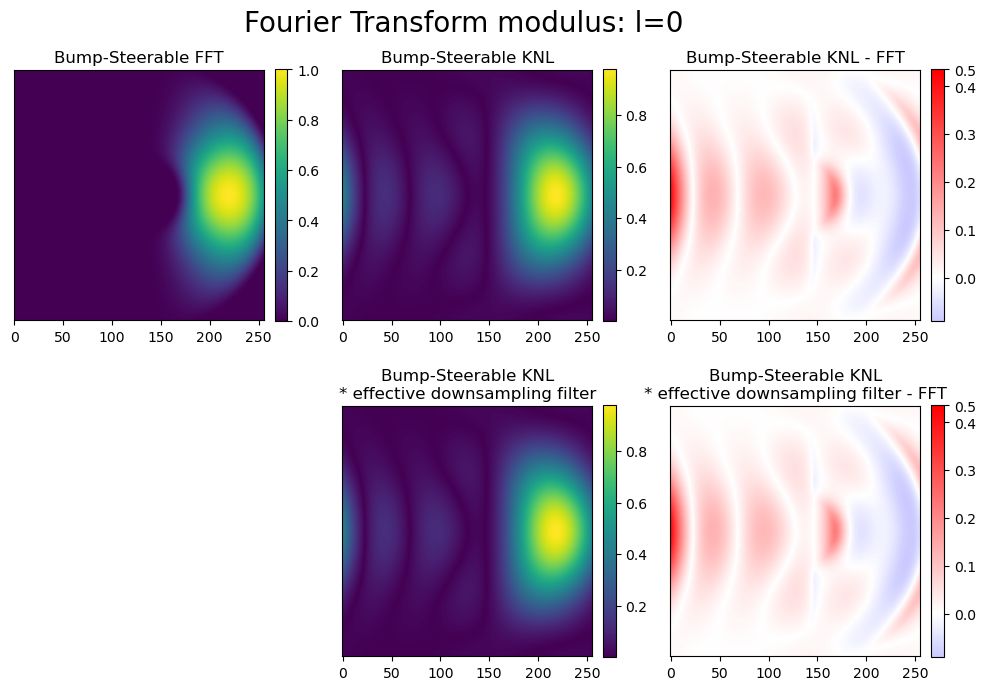

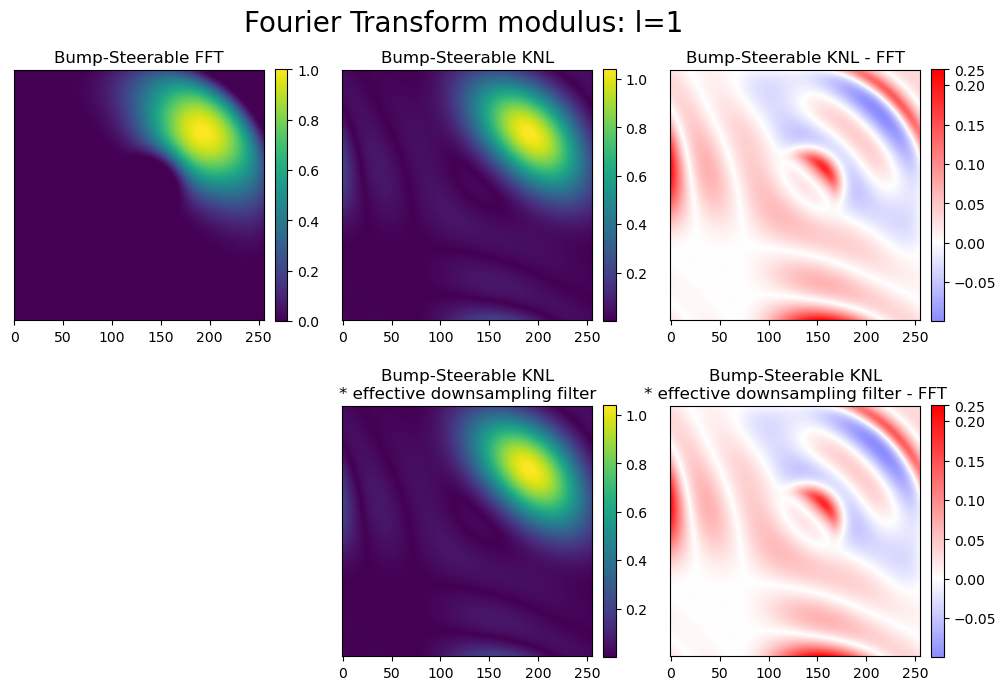

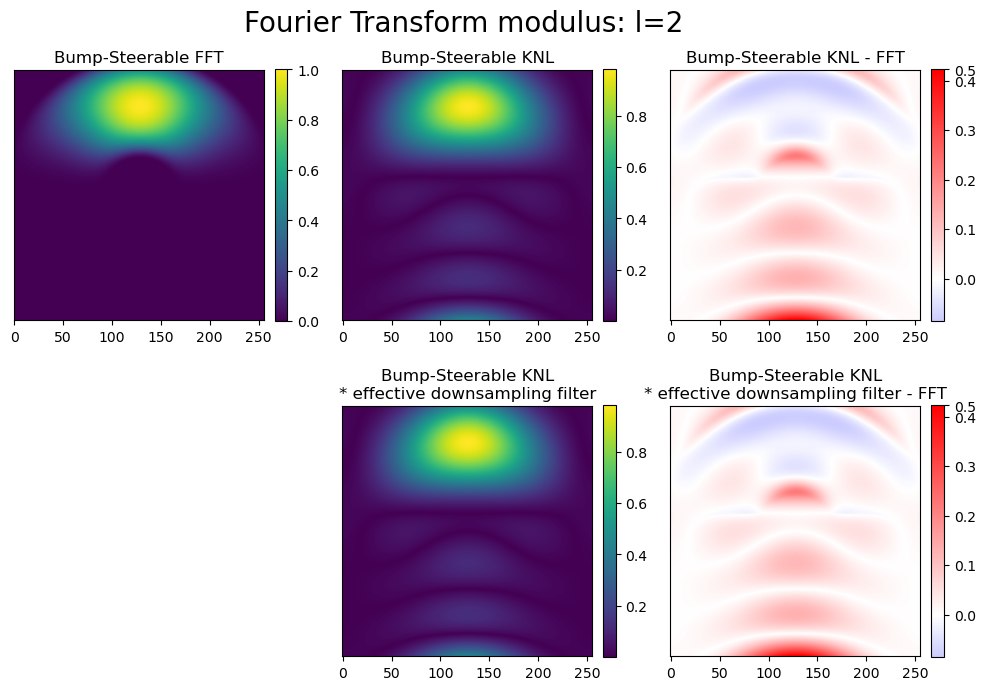

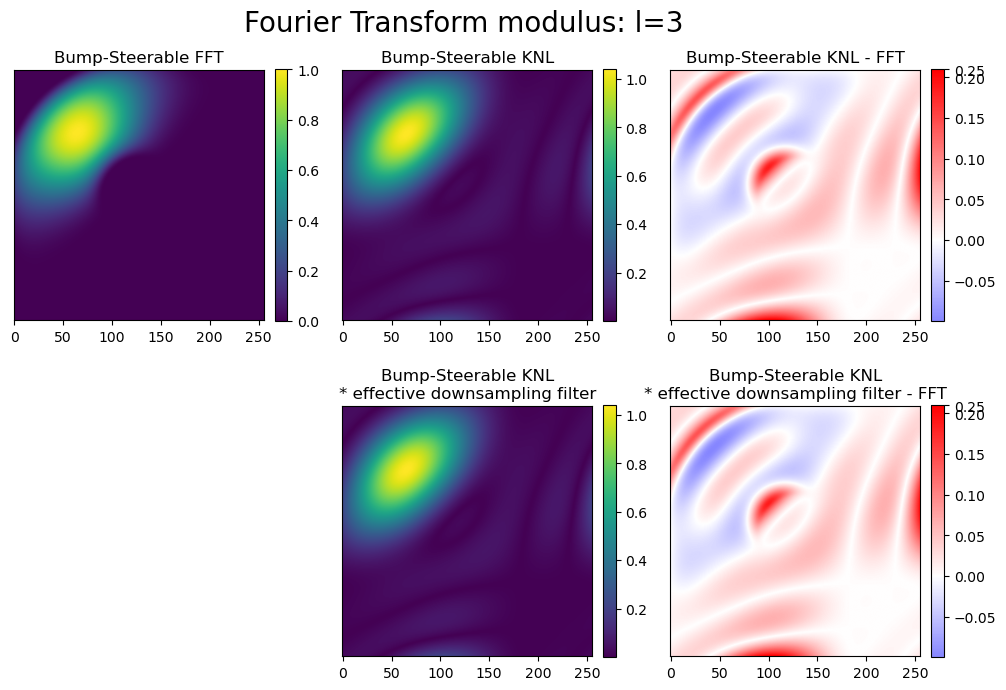

In [22]:
WType = "Bump-Steerable"
N = 256

st_op_kernel = st_ops_kernel[WType]
st_op_fft    =    st_ops_fft[WType]
effective_smooth_filter = 4 * get_effective_smooth_filter(2 * N, st_op_kernel, plot=False)[1]
    
for l, _wav_kernel in enumerate(st_op_kernel.wavelet_op._wav_kernel[0].cpu().numpy()):

    assert _wav_kernel.shape[0] % 2 == 1, "Wavelet kernel should have odd size for proper centering"
    w = _wav_kernel.shape[0] // 2

    wav_kernel = np.zeros((N, N), dtype=np.complex64)
    wav_kernel[N//2-w:N//2+w+1, N//2-w:N//2+w+1] = _wav_kernel
    wav_kernel = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(wav_kernel)))

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(np.abs(np.fft.fftshift(st_op_fft.wavelet_op.wavelet_array_MR[0][l].cpu().numpy())))
    plt.title(f'{WType} FFT')
    plt.gca().yaxis.set_visible(False)
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(2, 3, 2)
    plt.imshow(np.abs(wav_kernel))
    # add figtext to the top of the figure
    plt.figtext(0.5, 0.92, f'Fourier Transform modulus: l={l}', ha='center', va='center', fontsize=20)
    plt.title(f'{WType} KNL')
    plt.gca().yaxis.set_visible(False)
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(2, 3, 3)
    # make a colormap that is white at 0, but 0 is not espacially the center of the colormap, so that we can see the values around 0 more clearly
    to_plot = np.abs(wav_kernel) - np.abs(np.fft.fftshift(st_op_fft.wavelet_op.wavelet_array_MR[0][l].cpu().numpy()))
    plt.imshow(to_plot, cmap='bwr', norm=MidpointNormalize(midpoint=0))
    plt.title(f'{WType} KNL - FFT')
    plt.gca().yaxis.set_visible(False)
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(2, 3, 5)
    plt.imshow(np.abs(wav_kernel) * np.abs(np.fft.fftshift(effective_smooth_filter)))
    plt.title(f'{WType} KNL\n* effective downsampling filter')
    plt.gca().yaxis.set_visible(False)
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(2, 3, 6)
    to_plot = np.abs(wav_kernel) * np.abs(np.fft.fftshift(effective_smooth_filter)) - np.abs(np.fft.fftshift(st_op_fft.wavelet_op.wavelet_array_MR[0][l].cpu().numpy()))
    plt.imshow(to_plot, cmap='bwr', norm=MidpointNormalize(midpoint=0))
    plt.title(f'{WType} KNL\n* effective downsampling filter - FFT')
    plt.gca().yaxis.set_visible(False)
    plt.colorbar(fraction=0.046, pad=0.04)

#### Morlet

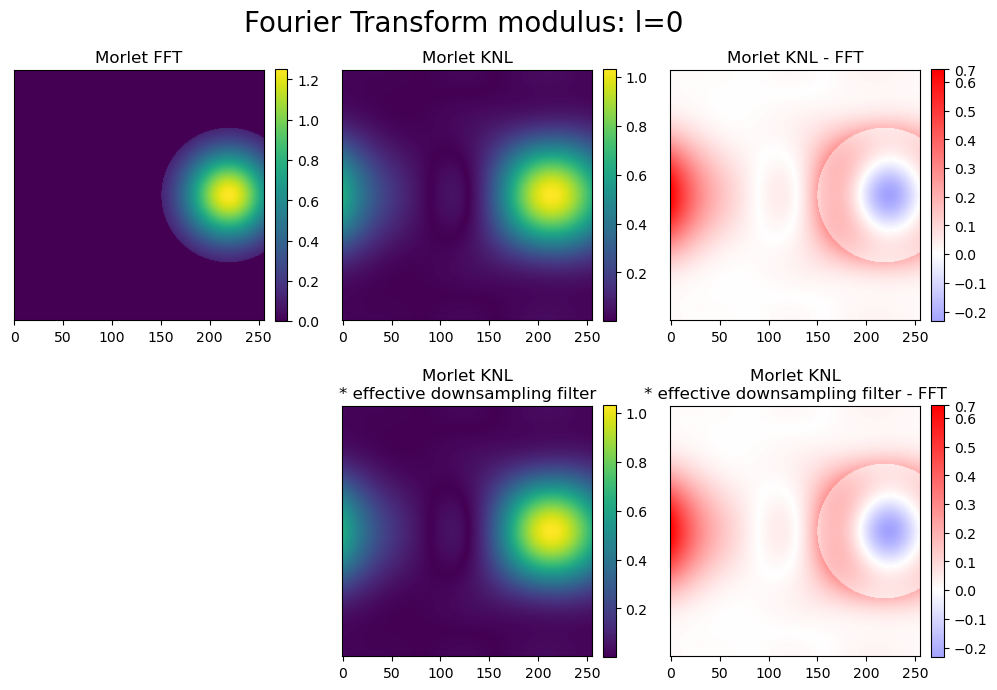

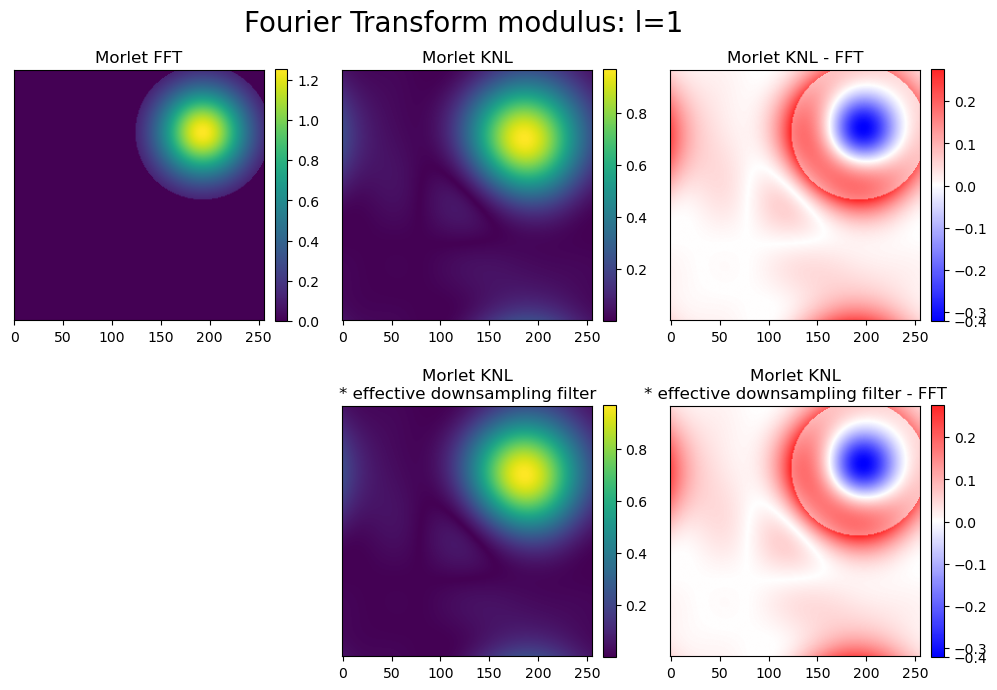

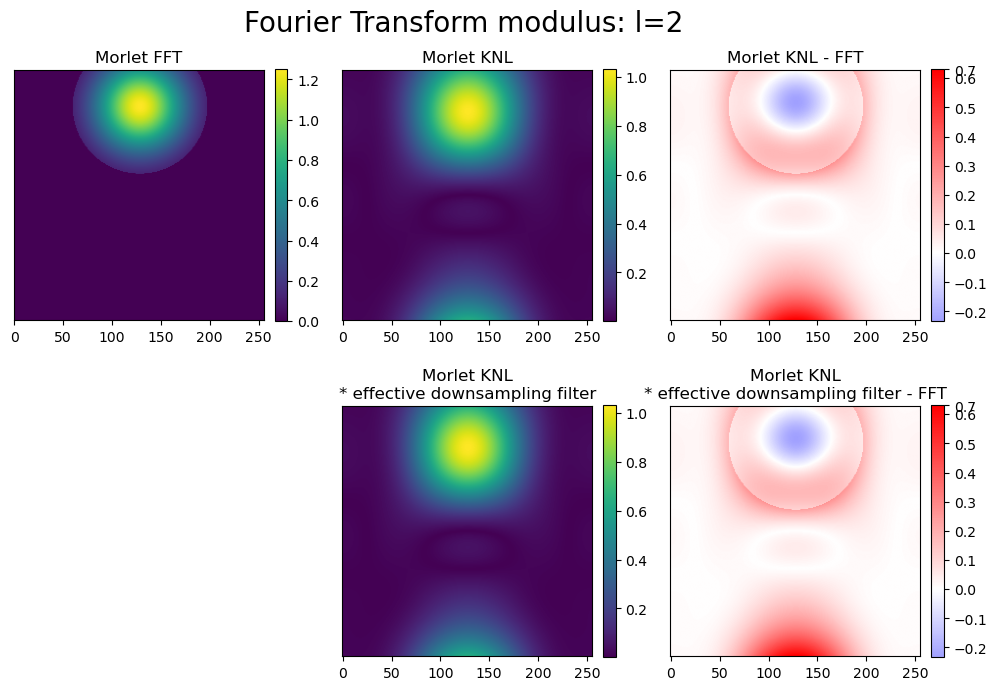

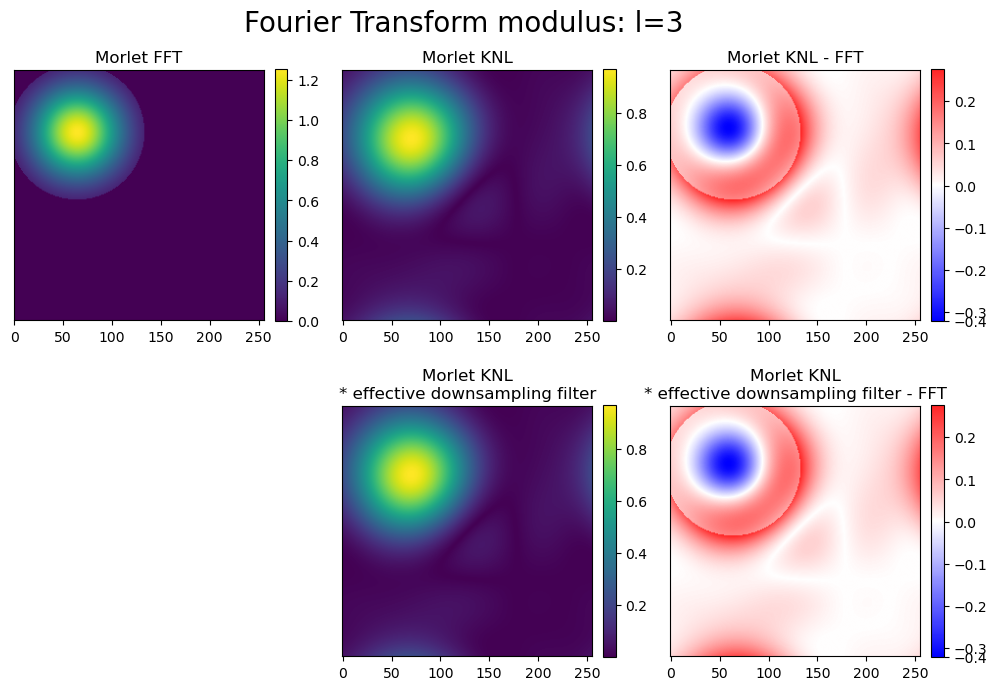

In [23]:
WType = "Morlet"
N = 256

st_op_kernel = st_ops_kernel[WType]
st_op_fft    =    st_ops_fft[WType]
effective_smooth_filter = 4 * get_effective_smooth_filter(2 * N, st_op_kernel, plot=False)[1]

for l, _wav_kernel in enumerate(st_op_kernel.wavelet_op._wav_kernel[0].cpu().numpy()):

    assert _wav_kernel.shape[0] % 2 == 1, "Wavelet kernel should have odd size for proper centering"
    w = _wav_kernel.shape[0] // 2

    wav_kernel = np.zeros((N, N), dtype=np.complex64)
    wav_kernel[N//2-w:N//2+w+1, N//2-w:N//2+w+1] = _wav_kernel
    wav_kernel = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(wav_kernel)))

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(np.abs(np.fft.fftshift(st_op_fft.wavelet_op.wavelet_array_MR[0][l].cpu().numpy())))
    plt.title(f'{WType} FFT')
    plt.gca().yaxis.set_visible(False)
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(2, 3, 2)
    plt.imshow(np.abs(wav_kernel))
    # add figtext to the top of the figure
    plt.figtext(0.5, 0.92, f'Fourier Transform modulus: l={l}', ha='center', va='center', fontsize=20)
    plt.title(f'{WType} KNL')
    plt.gca().yaxis.set_visible(False)
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(2, 3, 3)
    plt.imshow(np.abs(wav_kernel) - np.abs(np.fft.fftshift(st_op_fft.wavelet_op.wavelet_array_MR[0][l].cpu().numpy())), cmap='bwr', norm=MidpointNormalize(midpoint=0))
    plt.title(f'{WType} KNL - FFT')
    plt.gca().yaxis.set_visible(False)
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(2, 3, 5)
    plt.imshow(np.abs(wav_kernel) * np.abs(np.fft.fftshift(effective_smooth_filter)))
    plt.title(f'{WType} KNL\n* effective downsampling filter')
    plt.gca().yaxis.set_visible(False)
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(2, 3, 6)
    plt.imshow(np.abs(wav_kernel) * np.abs(np.fft.fftshift(effective_smooth_filter)) - np.abs(np.fft.fftshift(st_op_fft.wavelet_op.wavelet_array_MR[0][l].cpu().numpy())), cmap='bwr', norm=MidpointNormalize(midpoint=0))
    plt.title(f'{WType} KNL\n* effective downsampling filter - FFT')
    plt.gca().yaxis.set_visible(False)
    plt.colorbar(fraction=0.046, pad=0.04)

### In Real space

#### Bump-Steerable

In [24]:
WType = "Bump-Steerable"

##### FFT backend

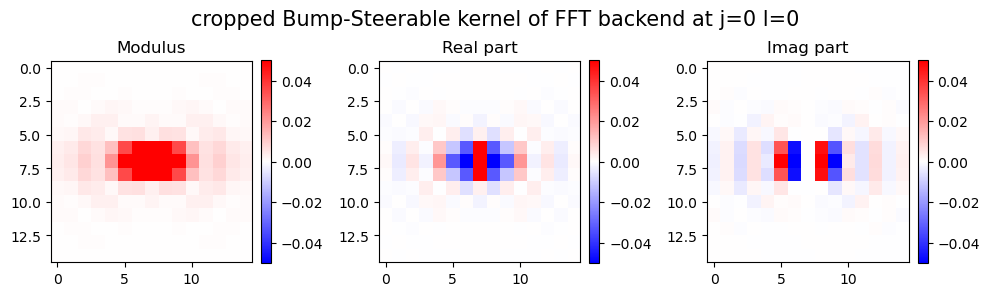

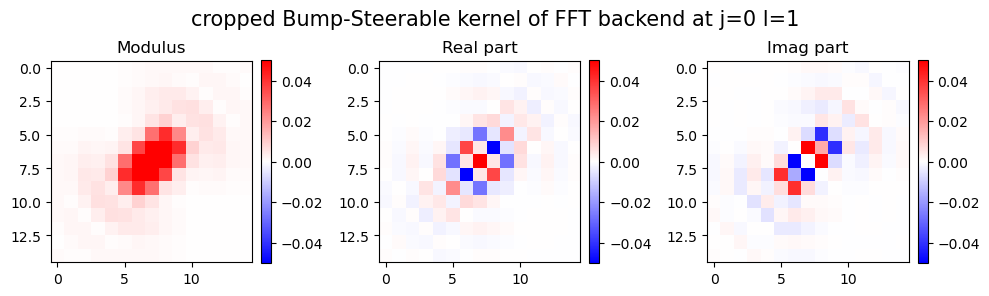

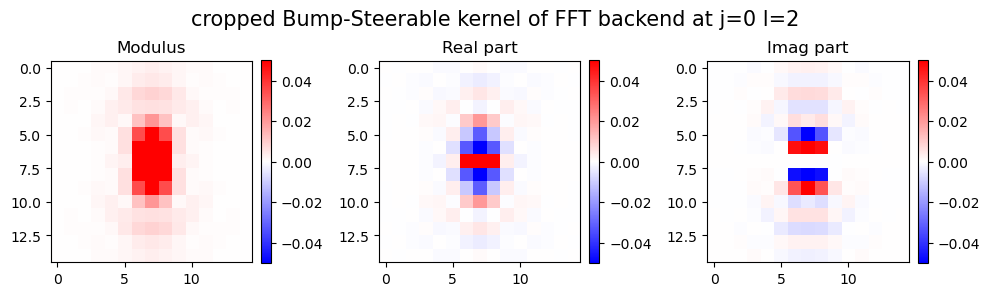

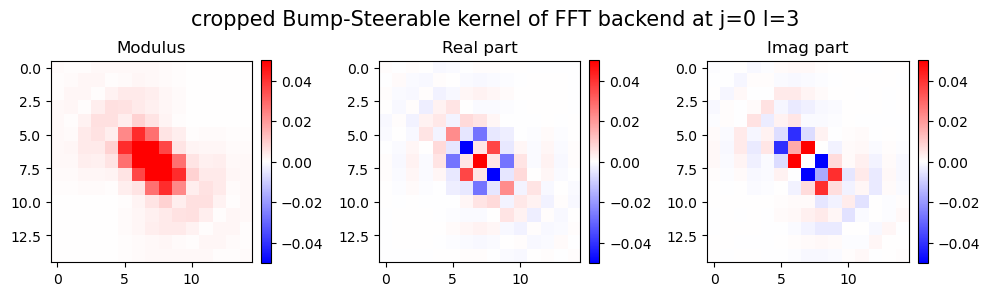

In [25]:
j = 0    
w = 7

for l, wav_kernel in enumerate(st_ops_fft[WType].wavelet_op.wavelet_array_MR[j].cpu().numpy()):

    bs_kernel = np.fft.fftshift(np.fft.ifft2(wav_kernel))

    # put the 3 plots in a single figure
    plt.figure(figsize=(10, 3))
    plt.subplot(1, 3, 1)
    plt.imshow(np.abs(bs_kernel)[N//2-w:N//2+w+1, N//2-w:N//2+w+1], cmap='bwr', vmin=-.05, vmax=.05)
    # add figtext to the top of the figure
    plt.figtext(0.5, 0.98, f'cropped {WType} kernel of FFT backend at j={j} l={l}', ha='center', va='center', fontsize=15)
    plt.title('Modulus')
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(1, 3, 2)
    plt.imshow(bs_kernel.real[N//2-w:N//2+w+1, N//2-w:N//2+w+1], cmap='bwr', vmin=-.05, vmax=.05)
    plt.title('Real part')
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(1, 3, 3)
    plt.imshow(bs_kernel.imag[N//2-w:N//2+w+1, N//2-w:N//2+w+1], cmap='bwr', vmin=-.05, vmax=.05)
    plt.title('Imag part')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

##### KNL backend

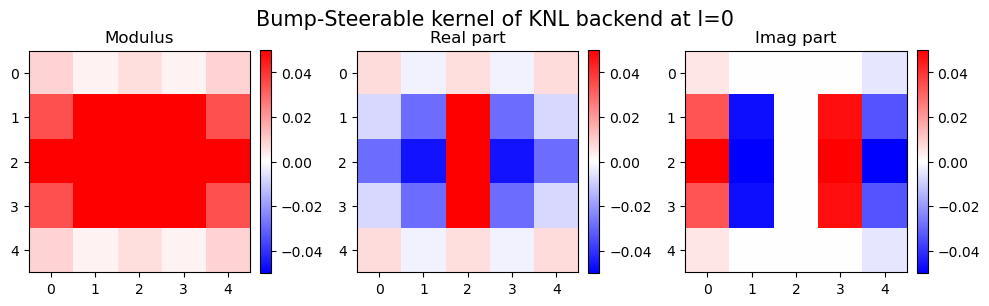

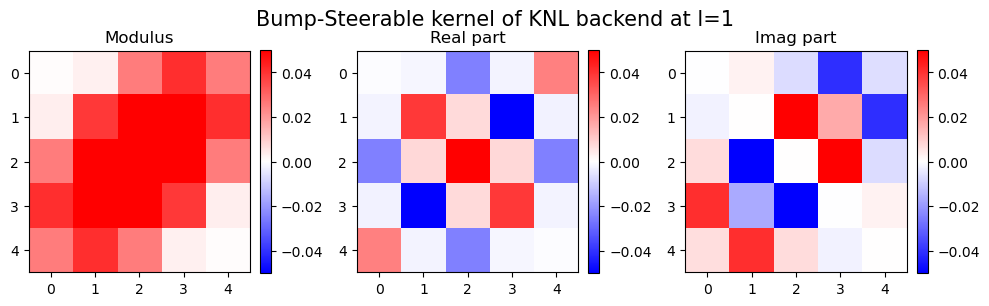

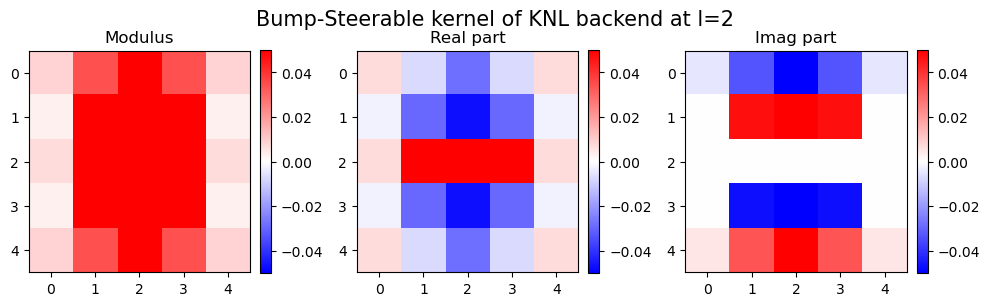

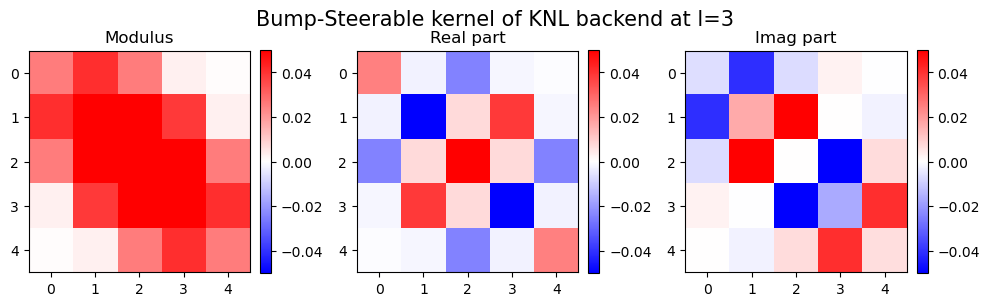

In [26]:
for l, wav_kernel in enumerate(st_ops_kernel[WType].wavelet_op._wav_kernel[0].cpu().numpy()):

    # put the 3 plots in a single figure
    plt.figure(figsize=(10, 3))
    plt.subplot(1, 3, 1)
    plt.imshow(np.abs(wav_kernel), cmap='bwr', vmin=-.05, vmax=.05)
    # add figtext to the top of the figure
    plt.figtext(0.5, 0.98, f'{WType} kernel of KNL backend at l={l}', ha='center', va='center', fontsize=15)
    plt.title('Modulus')
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(1, 3, 2)
    plt.imshow(wav_kernel.real, cmap='bwr', vmin=-.05, vmax=.05)
    plt.title('Real part')
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(1, 3, 3)
    plt.imshow(wav_kernel.imag, cmap='bwr', vmin=-.05, vmax=.05)
    plt.title('Imag part')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

#### Morlet

In [27]:
WType = "Morlet"

##### FFT backend

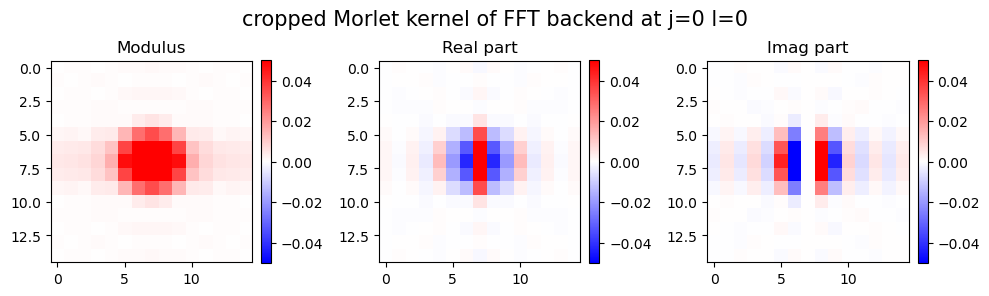

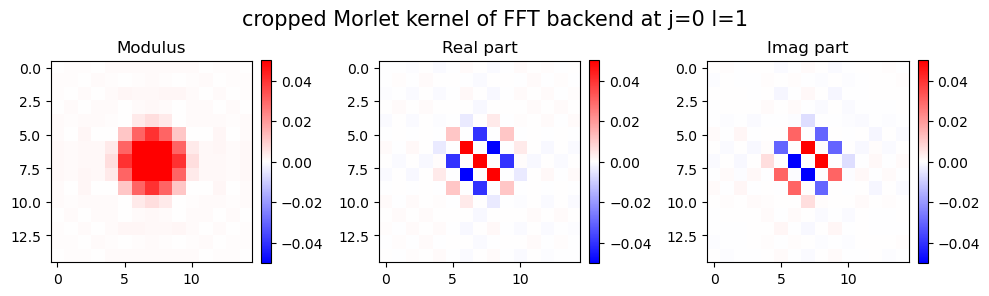

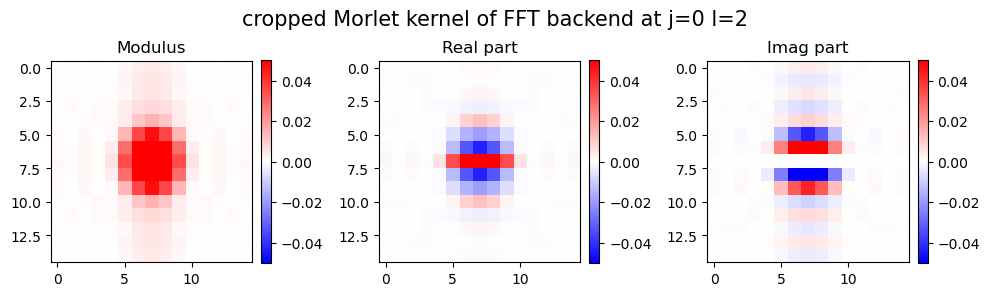

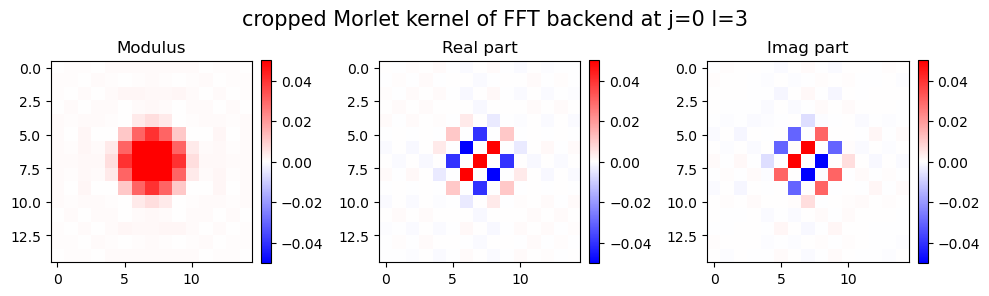

In [28]:
j = 0    
w = 7

for l, wav_kernel in enumerate(st_ops_fft[WType].wavelet_op.wavelet_array_MR[j].cpu().numpy()):

    bs_kernel = np.fft.fftshift(np.fft.ifft2(wav_kernel))

    # put the 3 plots in a single figure
    plt.figure(figsize=(10, 3))
    plt.subplot(1, 3, 1)
    plt.imshow(np.abs(bs_kernel)[N//2-w:N//2+w+1, N//2-w:N//2+w+1], cmap='bwr', vmin=-.05, vmax=.05)
    # add figtext to the top of the figure
    plt.figtext(0.5, 0.98, f'cropped {WType} kernel of FFT backend at j={j} l={l}', ha='center', va='center', fontsize=15)
    plt.title('Modulus')
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(1, 3, 2)
    plt.imshow(bs_kernel.real[N//2-w:N//2+w+1, N//2-w:N//2+w+1], cmap='bwr', vmin=-.05, vmax=.05)
    plt.title('Real part')
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(1, 3, 3)
    plt.imshow(bs_kernel.imag[N//2-w:N//2+w+1, N//2-w:N//2+w+1], cmap='bwr', vmin=-.05, vmax=.05)
    plt.title('Imag part')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

##### KNL backend

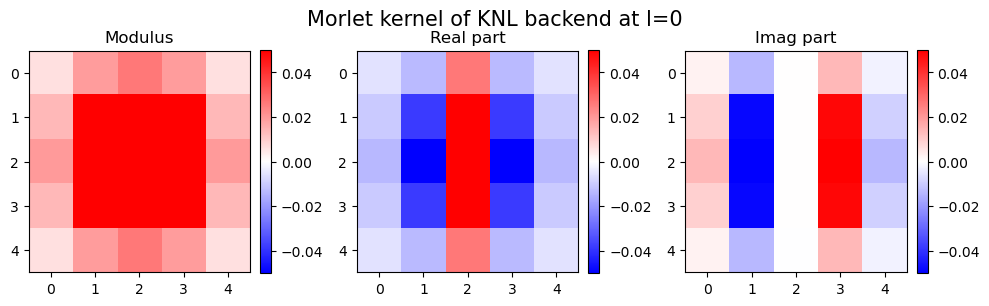

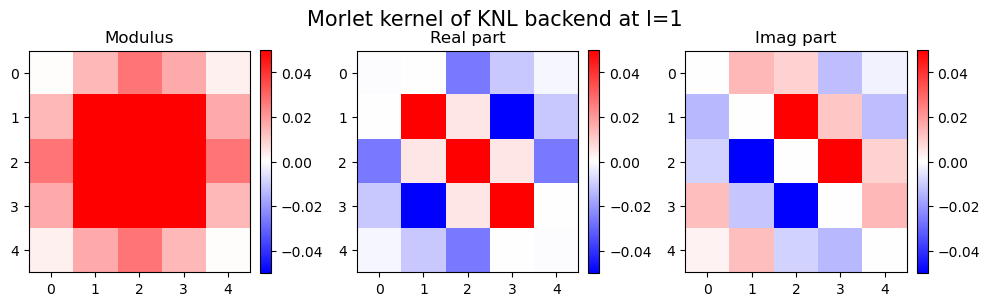

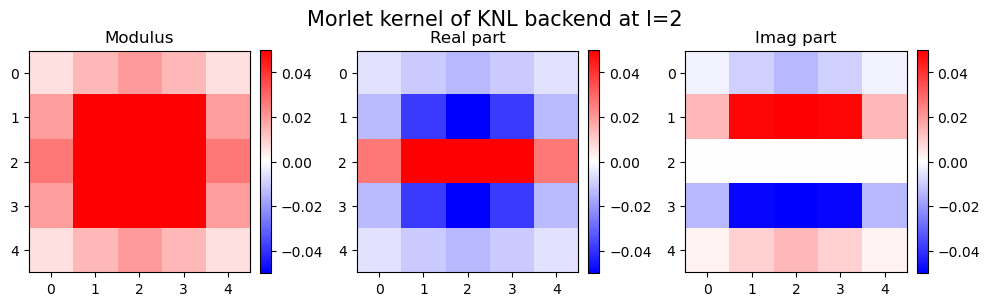

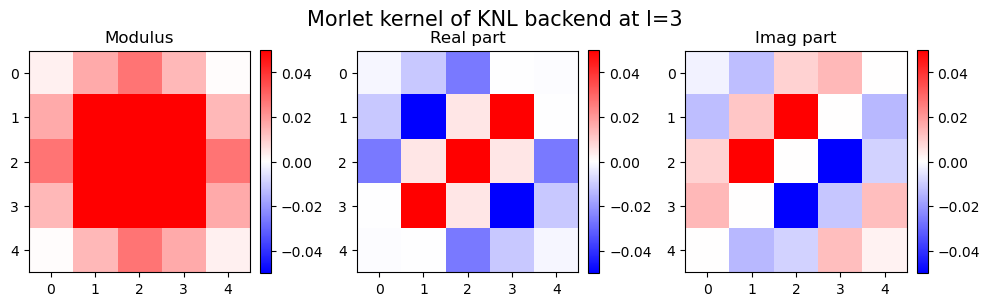

In [29]:
for l, wav_kernel in enumerate(st_ops_kernel[WType].wavelet_op._wav_kernel[0].cpu().numpy()):

    # put the 3 plots in a single figure
    plt.figure(figsize=(10, 3))
    plt.subplot(1, 3, 1)
    plt.imshow(np.abs(wav_kernel), cmap='bwr', vmin=-.05, vmax=.05)
    # add figtext to the top of the figure
    plt.figtext(0.5, 0.98, f'{WType} kernel of KNL backend at l={l}', ha='center', va='center', fontsize=15)
    plt.title('Modulus')
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(1, 3, 2)
    plt.imshow(wav_kernel.real, cmap='bwr', vmin=-.05, vmax=.05)
    plt.title('Real part')
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(1, 3, 3)
    plt.imshow(wav_kernel.imag, cmap='bwr', vmin=-.05, vmax=.05)
    plt.title('Imag part')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

## Test Littlewood-Paley condition

In [30]:
def plot_LP(sum, title, vmin=0, vmax=.7):
    cmap = 'jet' if vmin >= 0 else 'bwr'

    ticks = [0, 5, 10, 20, 35, 50, 75, 100, 150, 200, 300] if vmin >= 0 else [-300, -200, -150, -100, -75, -50, -35, -20, -10, -5, 0, 5, 10, 20, 35, 50, 75, 100, 150, 200, 300]
    ticklabels = [f"{tick}%" for tick in ticks]
    ticks = np.log2(1. + np.array(ticks) / 100.)

    # make 2 plots of the sum, one with log scale and one without, side by side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 2)
    plt.imshow(np.abs(np.log2(sum)) if vmin >= 0 else np.log2(sum), cmap=cmap, vmin=vmin, vmax=vmax)

    sum += sum[::-1,::-1]
    plt.subplot(1, 2, 1)
    plt.imshow(np.abs(np.log2(sum)) if vmin >= 0 else np.log2(sum), cmap=cmap, vmin=vmin, vmax=vmax)
    plt.tight_layout()
    # add a colorbar to the right of the two plots with specific ticks and labels
    cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), 
                        ax=plt.gcf().get_axes(), orientation='horizontal', fraction=0.08, pad=0.08, 
                        extend='both' if vmin < 0 else 'max',
                        ticks=ticks, label="Unsigned energy distortion (%) (shrinkage or amplification)" if vmin >= 0 else "Energy distortion (%)")
    cbar.set_ticklabels(ticklabels)

    # add a title to the figure
    plt.suptitle(title, fontsize=14, y=1.02)
    plt.show()

/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:6: RuntimeWarning: divide by zero encountered in log2
  ticks = np.log2(1. + np.array(ticks) / 100.)
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:6: RuntimeWarning: invalid value encountered in log2
  ticks = np.log2(1. + np.array(ticks) / 100.)
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:11: RuntimeWarning: divide by zero encountered in log2
  plt.imshow(np.abs(np.log2(sum)) if vmin >= 0 else np.log2(sum), cmap=cmap, vmin=vmin, vmax=vmax)
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:15: RuntimeWarning: divide by zero encountered in log2
  plt.imshow(np.abs(np.log2(sum)) if vmin >= 0 else np.log2(sum), cmap=cmap, vmin=vmin, vmax=vmax)


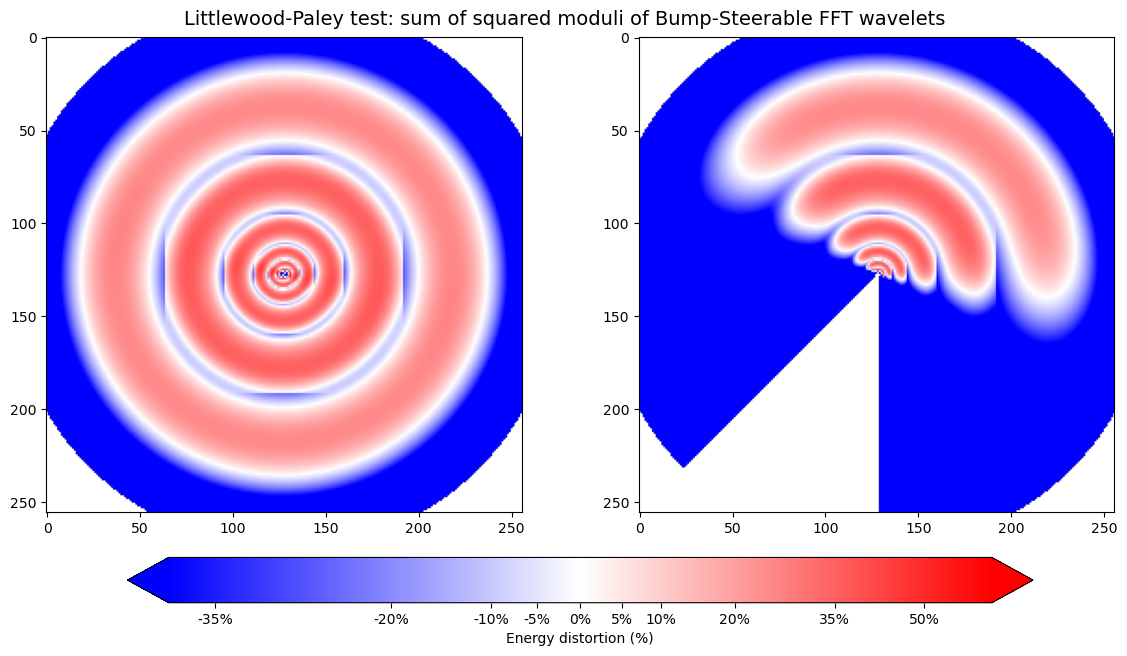

/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/3265358957.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  wav_kernel[:,N//2-w:N//2+w, N//2-w:N//2+w] = wav_kernel_small
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:6: RuntimeWarning: divide by zero encountered in log2
  ticks = np.log2(1. + np.array(ticks) / 100.)
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:6: RuntimeWarning: invalid value encountered in log2
  ticks = np.log2(1. + np.array(ticks) / 100.)


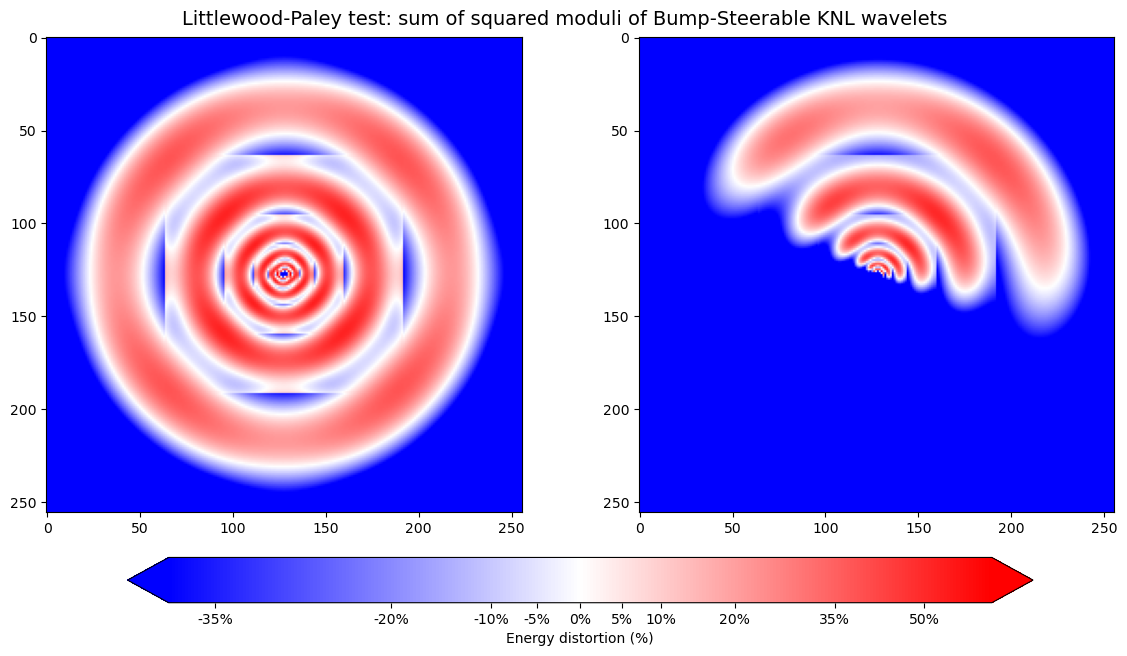

/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:6: RuntimeWarning: divide by zero encountered in log2
  ticks = np.log2(1. + np.array(ticks) / 100.)
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:6: RuntimeWarning: invalid value encountered in log2
  ticks = np.log2(1. + np.array(ticks) / 100.)


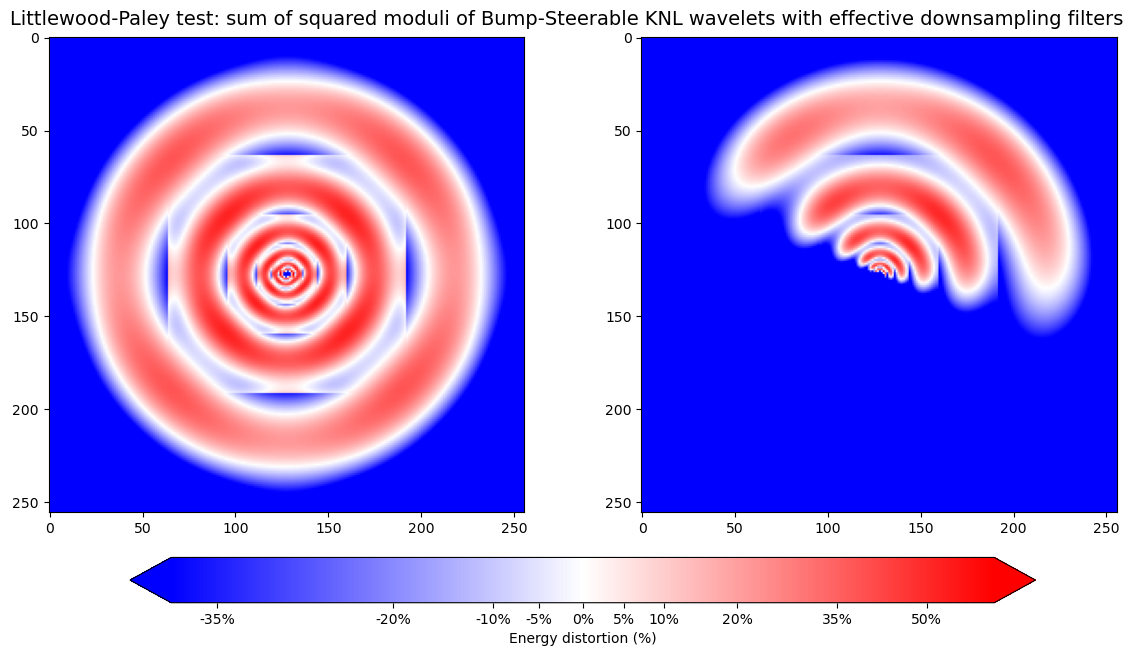

/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:6: RuntimeWarning: divide by zero encountered in log2
  ticks = np.log2(1. + np.array(ticks) / 100.)
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:6: RuntimeWarning: invalid value encountered in log2
  ticks = np.log2(1. + np.array(ticks) / 100.)
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:11: RuntimeWarning: divide by zero encountered in log2
  plt.imshow(np.abs(np.log2(sum)) if vmin >= 0 else np.log2(sum), cmap=cmap, vmin=vmin, vmax=vmax)
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:15: RuntimeWarning: divide by zero encountered in log2
  plt.imshow(np.abs(np.log2(sum)) if vmin >= 0 else np.log2(sum), cmap=cmap, vmin=vmin, vmax=vmax)


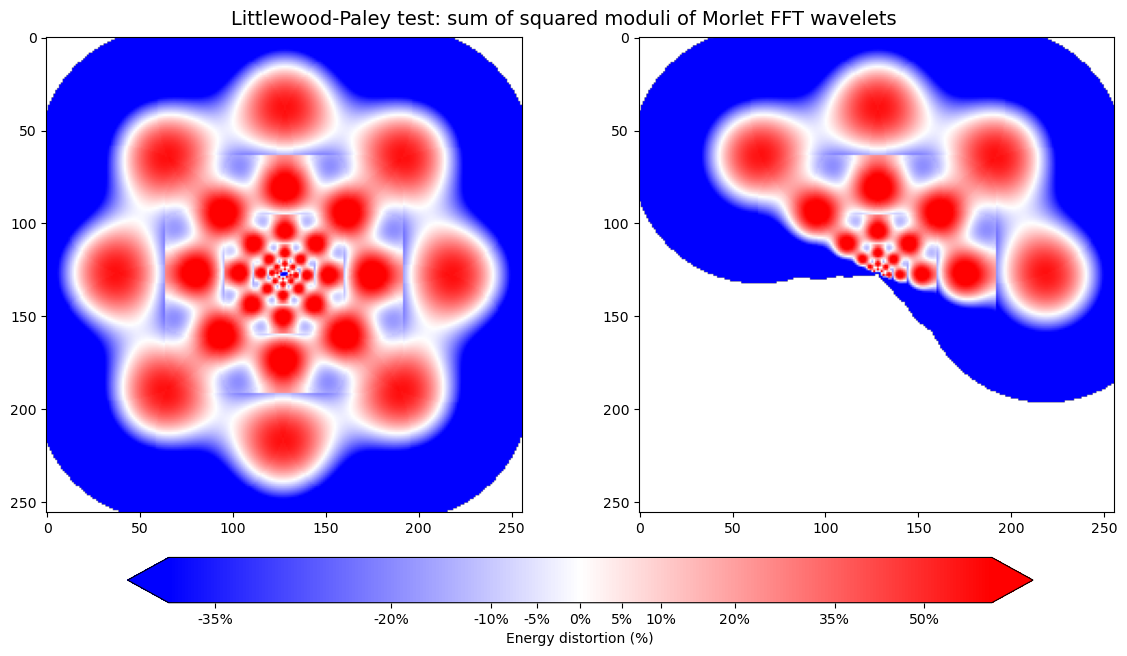

/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/3265358957.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  wav_kernel[:,N//2-w:N//2+w, N//2-w:N//2+w] = wav_kernel_small
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:6: RuntimeWarning: divide by zero encountered in log2
  ticks = np.log2(1. + np.array(ticks) / 100.)
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:6: RuntimeWarning: invalid value encountered in log2
  ticks = np.log2(1. + np.array(ticks) / 100.)


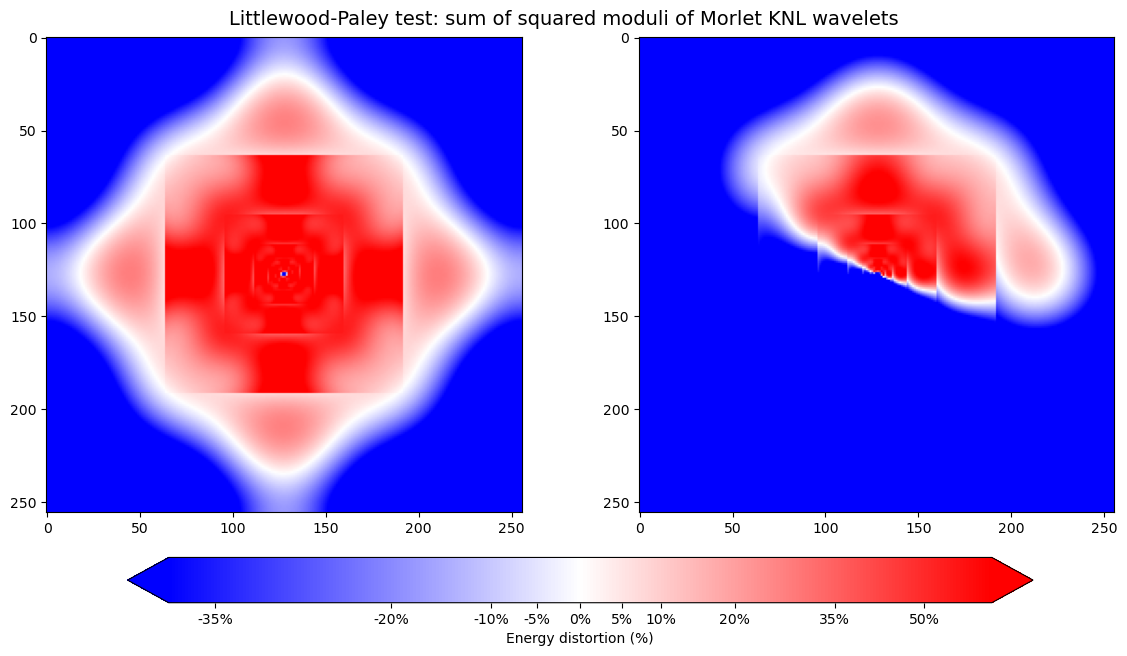

/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:6: RuntimeWarning: divide by zero encountered in log2
  ticks = np.log2(1. + np.array(ticks) / 100.)
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:6: RuntimeWarning: invalid value encountered in log2
  ticks = np.log2(1. + np.array(ticks) / 100.)


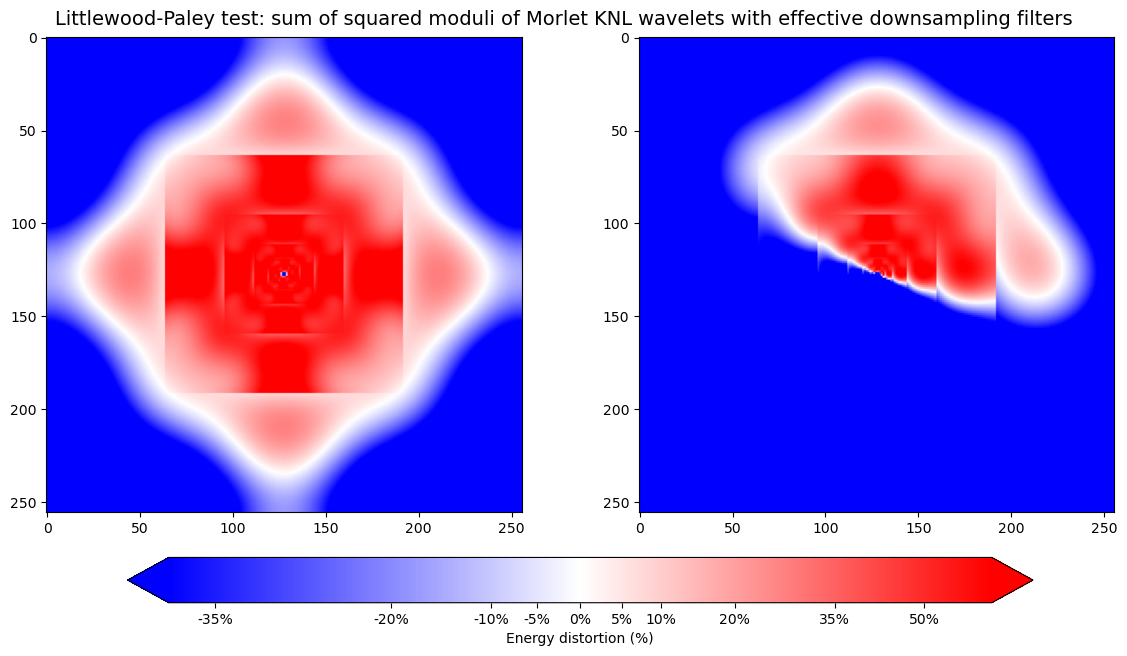

In [31]:
vmin = -.7

for WType in WTypes:
        
    sum = np.zeros((N, N))

    for dg, _wav_kernel in enumerate(st_ops_fft[WType].wavelet_op.wavelet_array_MR):
        wav_kernel = np.zeros((L, N, N))
        w = _wav_kernel.shape[1]//2
        wav_kernel[:,N//2-w:N//2+w, N//2-w:N//2+w] = np.fft.fftshift(_wav_kernel.cpu().numpy(), axes=(1, 2))
        sum += (np.abs(wav_kernel)**2).sum(axis=0)

    plot_LP(sum, vmin=vmin, vmax=-vmin, title=f"Littlewood-Paley test: sum of squared moduli of {WType} FFT wavelets")



    cropped_wav_kernel = st_ops_kernel[WType].wavelet_op._wav_kernel[0].cpu().numpy()

    sum = np.zeros((N, N))

    for dg in range(st_ops_kernel[WType].J):

        w = cropped_wav_kernel.shape[1]//2

        wav_kernel = np.zeros((L, N // 2**dg, N // 2**dg), dtype=np.complex64)
        wav_kernel[:,N//2**(dg+1)-w:N//2**(dg+1)+w+1, N//2**(dg+1)-w:N//2**(dg+1)+w+1] = cropped_wav_kernel
        wav_kernel_small = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(wav_kernel, axes=(1, 2))), axes=(1, 2))

        wav_kernel = np.zeros((L, N, N))
        w = wav_kernel_small.shape[1]//2
        wav_kernel[:,N//2-w:N//2+w, N//2-w:N//2+w] = wav_kernel_small
        sum += (np.abs(wav_kernel)**2).sum(axis=0)

    plot_LP(sum, vmin=vmin, vmax=-vmin, title=f"Littlewood-Paley test: sum of squared moduli of {WType} KNL wavelets")


    effective_smooth_filters = get_effective_smooth_filter(N, st_ops_kernel[WType], plot=False)

    sum = np.zeros((N, N))

    for dg in range(st_ops_kernel[WType].J):

        w = cropped_wav_kernel.shape[1]//2

        wav_kernel = np.zeros((L, N // 2**dg, N // 2**dg), dtype=np.complex64)
        wav_kernel[:,N//2**(dg+1)-w:N//2**(dg+1)+w+1, N//2**(dg+1)-w:N//2**(dg+1)+w+1] = cropped_wav_kernel
        wav_kernel_small = np.fft.fftshift(effective_smooth_filters[dg] * 4**dg * np.fft.fft2(np.fft.ifftshift(wav_kernel, axes=(1, 2))), axes=(1, 2))


        wav_kernel = np.zeros((L, N, N), dtype=np.complex64)
        w = wav_kernel_small.shape[1]//2
        wav_kernel[:,N//2-w:N//2+w, N//2-w:N//2+w] = wav_kernel_small

        sum += (np.abs(wav_kernel)**2).sum(axis=0)

    plot_LP(sum, vmin=vmin, vmax=-vmin, title=f"Littlewood-Paley test: sum of squared moduli of {WType} KNL wavelets with effective downsampling filters")

/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:11: RuntimeWarning: divide by zero encountered in log2
  plt.imshow(np.abs(np.log2(sum)) if vmin >= 0 else np.log2(sum), cmap=cmap, vmin=vmin, vmax=vmax)
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:15: RuntimeWarning: divide by zero encountered in log2
  plt.imshow(np.abs(np.log2(sum)) if vmin >= 0 else np.log2(sum), cmap=cmap, vmin=vmin, vmax=vmax)


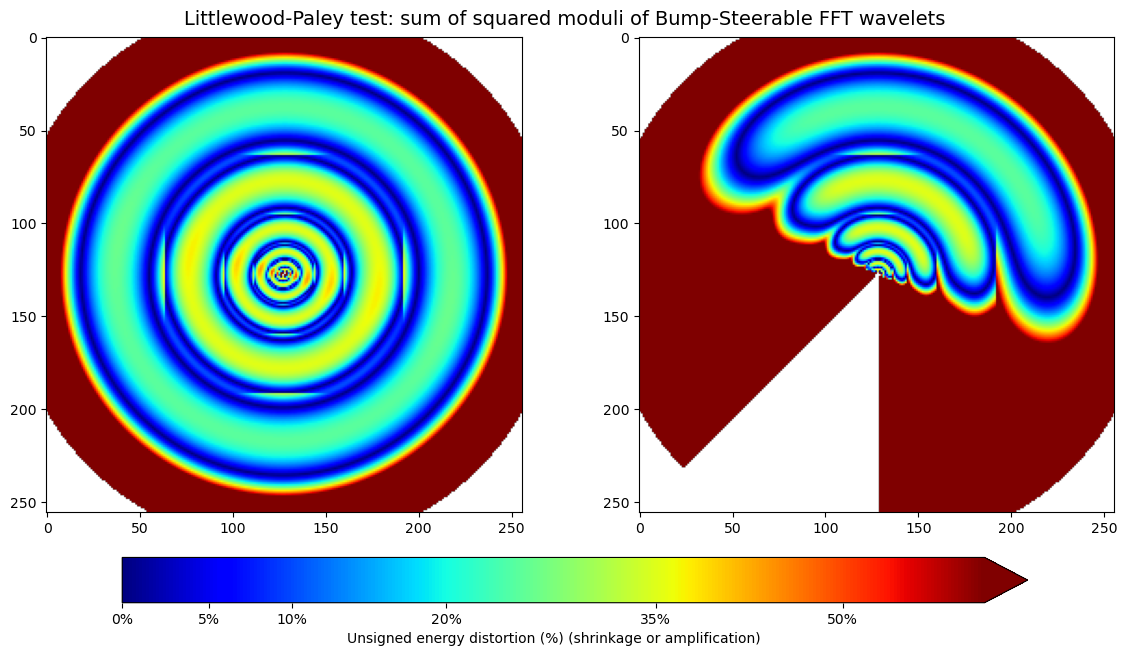

/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/3272897710.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  wav_kernel[:,N//2-w:N//2+w, N//2-w:N//2+w] = wav_kernel_small


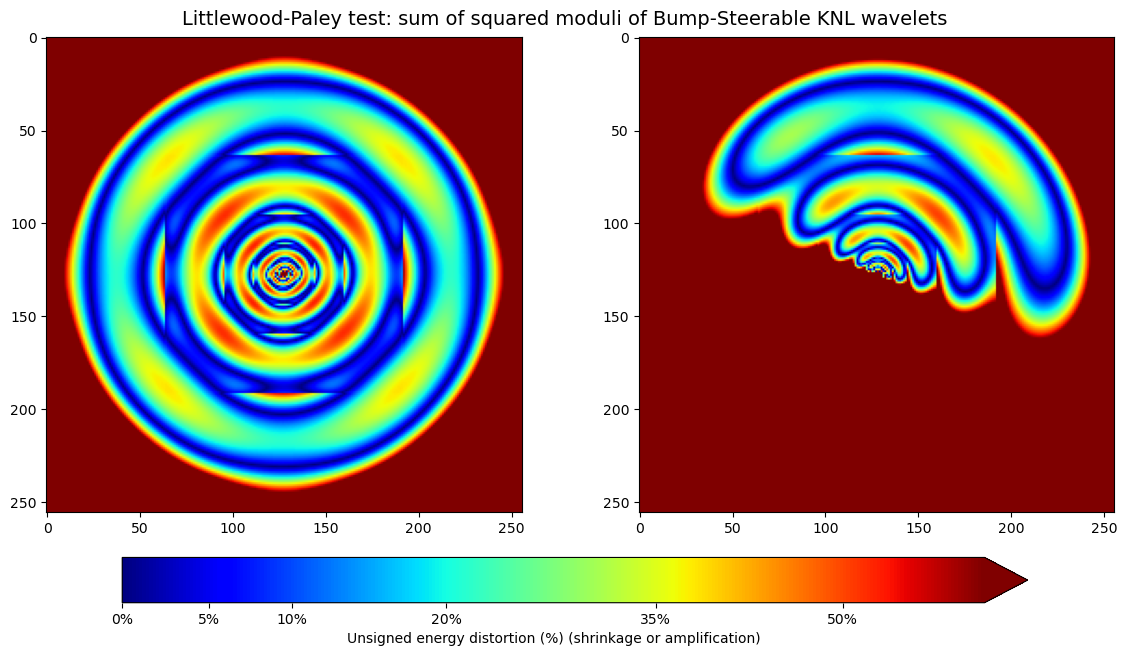

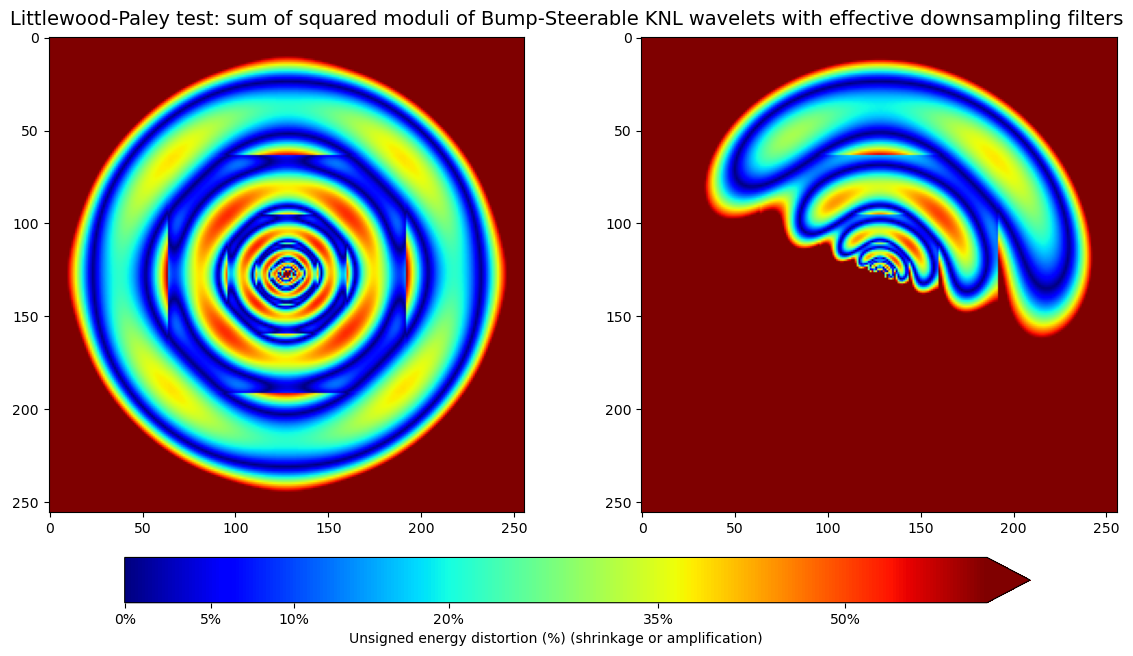

/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:11: RuntimeWarning: divide by zero encountered in log2
  plt.imshow(np.abs(np.log2(sum)) if vmin >= 0 else np.log2(sum), cmap=cmap, vmin=vmin, vmax=vmax)
/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/2043011486.py:15: RuntimeWarning: divide by zero encountered in log2
  plt.imshow(np.abs(np.log2(sum)) if vmin >= 0 else np.log2(sum), cmap=cmap, vmin=vmin, vmax=vmax)


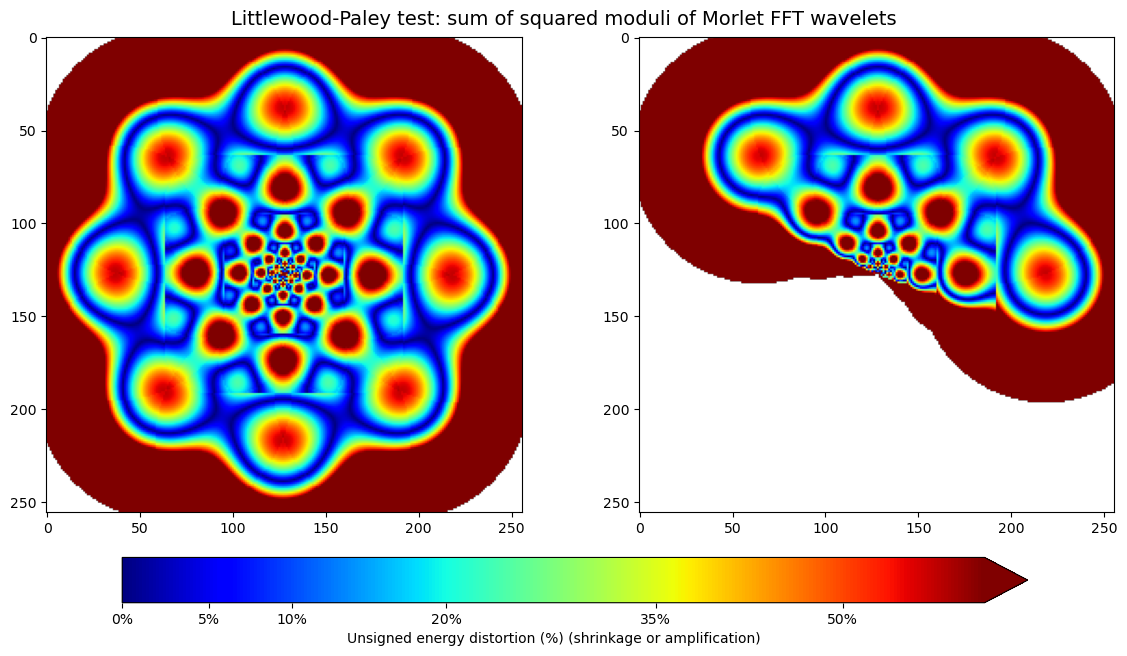

/var/folders/fn/x6crbtrd08b_gtsnsyrybdfc0000gp/T/ipykernel_30999/3272897710.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  wav_kernel[:,N//2-w:N//2+w, N//2-w:N//2+w] = wav_kernel_small


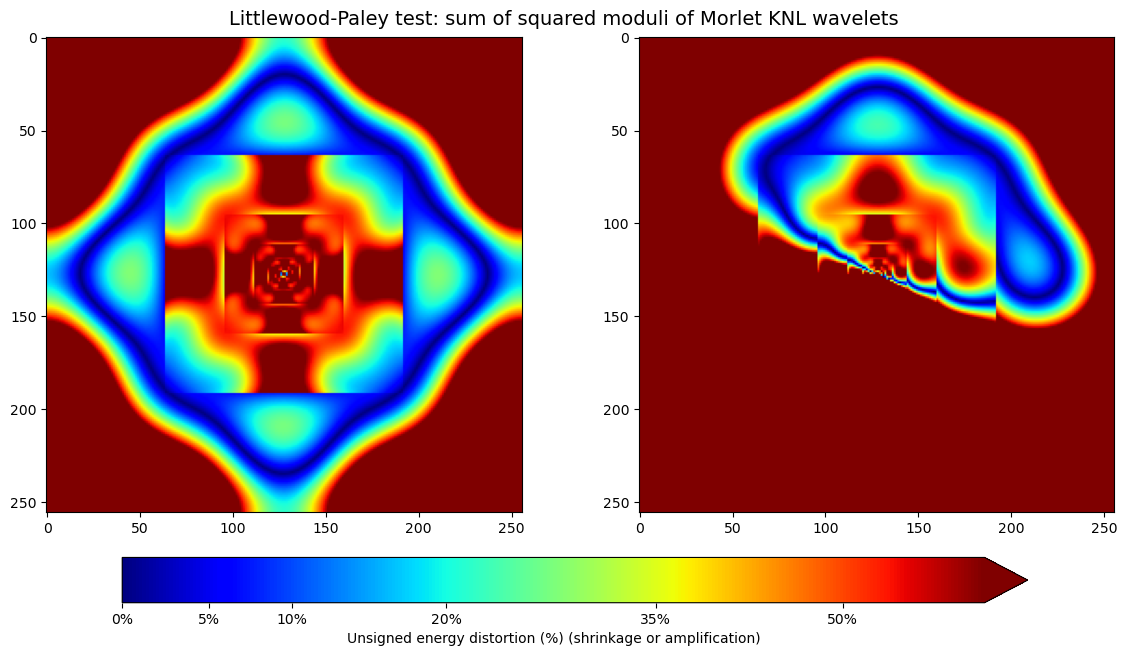

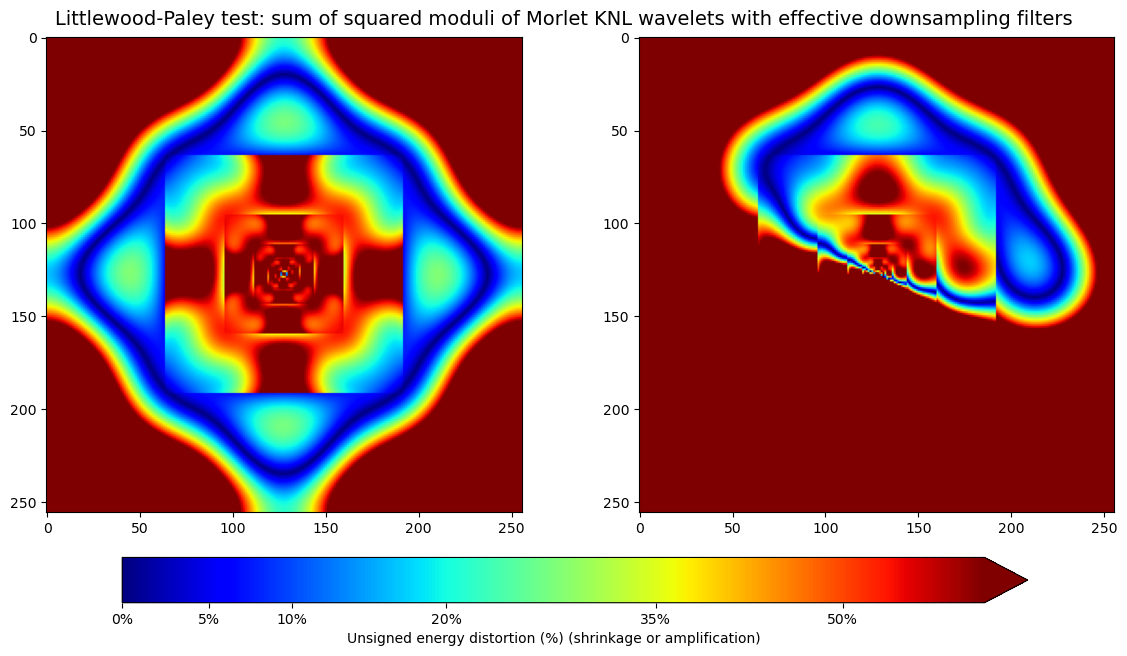

In [32]:
for WType in WTypes:
        
    sum = np.zeros((N, N))

    for dg, _wav_kernel in enumerate(st_ops_fft[WType].wavelet_op.wavelet_array_MR):
        wav_kernel = np.zeros((L, N, N))
        w = _wav_kernel.shape[1]//2
        wav_kernel[:,N//2-w:N//2+w, N//2-w:N//2+w] = np.fft.fftshift(_wav_kernel.cpu().numpy(), axes=(1, 2))
        sum += (np.abs(wav_kernel)**2).sum(axis=0)

    plot_LP(sum, title=f"Littlewood-Paley test: sum of squared moduli of {WType} FFT wavelets")



    cropped_wav_kernel = st_ops_kernel[WType].wavelet_op._wav_kernel[0].cpu().numpy()

    sum = np.zeros((N, N))

    for dg in range(st_ops_kernel[WType].J):

        w = cropped_wav_kernel.shape[1]//2

        wav_kernel = np.zeros((L, N // 2**dg, N // 2**dg), dtype=np.complex64)
        wav_kernel[:,N//2**(dg+1)-w:N//2**(dg+1)+w+1, N//2**(dg+1)-w:N//2**(dg+1)+w+1] = cropped_wav_kernel
        wav_kernel_small = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(wav_kernel, axes=(1, 2))), axes=(1, 2))

        wav_kernel = np.zeros((L, N, N))
        w = wav_kernel_small.shape[1]//2
        wav_kernel[:,N//2-w:N//2+w, N//2-w:N//2+w] = wav_kernel_small
        sum += (np.abs(wav_kernel)**2).sum(axis=0)

    plot_LP(sum, title=f"Littlewood-Paley test: sum of squared moduli of {WType} KNL wavelets")


    effective_smooth_filters = get_effective_smooth_filter(N, st_ops_kernel[WType], plot=False)

    sum = np.zeros((N, N))

    for dg in range(st_ops_kernel[WType].J):

        w = cropped_wav_kernel.shape[1]//2

        wav_kernel = np.zeros((L, N // 2**dg, N // 2**dg), dtype=np.complex64)
        wav_kernel[:,N//2**(dg+1)-w:N//2**(dg+1)+w+1, N//2**(dg+1)-w:N//2**(dg+1)+w+1] = cropped_wav_kernel
        wav_kernel_small = np.fft.fftshift(effective_smooth_filters[dg] * 4**dg * np.fft.fft2(np.fft.ifftshift(wav_kernel, axes=(1, 2))), axes=(1, 2))


        wav_kernel = np.zeros((L, N, N), dtype=np.complex64)
        w = wav_kernel_small.shape[1]//2
        wav_kernel[:,N//2-w:N//2+w, N//2-w:N//2+w] = wav_kernel_small

        sum += (np.abs(wav_kernel)**2).sum(axis=0)

    plot_LP(sum, title=f"Littlewood-Paley test: sum of squared moduli of {WType} KNL wavelets with effective downsampling filters")